### initialize

In [3]:
# =============================================================================
# CELL 1: Imports and Setup
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Add path for data loader
sys.path.append(r'D:\Neural-Pipeline\source')

# Setup parameters
subject = "zarya"
dates = ["20250702", "20250710", "20250523", "20250501", "20250417", "20250602"]
regress_type = 'noregress'

print(f"Subject: {subject}")
print(f"Sessions: {len(dates)}")
print(f"Regression type: {regress_type}")

def load_decoder_results(subject, date, area, target, alignment, train_mod, train_coh, 
                         test_mod=None, test_coh=None, regress_type='noregress'):
    """Load saved decoder results."""
    test_mod = test_mod or train_mod
    test_coh = test_coh or train_coh
    save_dir = Path(rf'D:\Neural-Pipeline\results\analysis_pseudopopulation\decoders_{regress_type}')
    filename = (f"{subject}_{date}_{area}_{target}_{alignment}_"
                f"train_mod{train_mod}_coh{train_coh}_"
                f"test_mod{test_mod}_coh{test_coh}_results.npy")
    filepath = save_dir / filename
    return np.load(filepath, allow_pickle=True).item() if filepath.exists() else None

def load_time_axes_only(subject, date):
    """Load time axes for a given subject and date."""
    import sys
    sys.path.append(r'D:\Neural-Pipeline\source')
    from analysis_utils.NeuralDataLoader import NeuralDataLoader, Dots3DMPConfig
    loader = NeuralDataLoader()
    loader.load_session(subject, date)
    return Dots3DMPConfig(subject).get_time_axes('dots3DMP')


# =============================================================================
# CELL 3: Trial-level DV Extraction Functions
# =============================================================================

def extract_trial_dv_timecourse(results, test_set='test_cv', target='choice'):
    """Extract full timecourse of DV for each individual trial."""
    trial_results = results['trial_results']
    n_trials = None
    trial_data = {}
    
    for r in trial_results:
        t = r['time']
        
        if test_set not in r:
            continue
            
        y_proba = r[test_set].get('y_proba', np.array([]))
        behavior = r[test_set].get('behavior', {})
        
        if len(y_proba) == 0 or len(behavior) == 0:
            continue
        
        # Initialize trial structure if first time point
        if n_trials is None:
            n_trials = len(y_proba)
            for i in range(n_trials):
                trial_data[i] = {'dv': [], 'times': [], 'behavior': behavior}
        
        # Compute DVs
        y_proba_clipped = np.clip(y_proba, 1e-10, 1 - 1e-10)
        raw_logodds = np.log(y_proba_clipped / (1 - y_proba_clipped))
        
        # Get labels for flipping
        if target == 'choice':
            label = np.array(behavior.get('choice', []))
            label = (label - 1).astype(int) if len(label) > 0 and np.max(label) > 1 else label
        elif target == 'PDW':
            label = np.array(behavior.get('PDW', [])).astype(int) if 'PDW' in behavior else np.array([])
        else:  # stimulus
            headingInd = np.array(behavior.get('headingInd', []))
            if test_set == 'test_zero':
                label = np.ones(len(raw_logodds))
            else:
                label = (headingInd > 4).astype(int)
        
        if len(label) != len(raw_logodds):
            continue
        
        # Flip DV for class 0 trials
        flipped_logodds = raw_logodds.copy()
        class0_mask = label == 0
        flipped_logodds[class0_mask] = -flipped_logodds[class0_mask]
        
        # Store for each trial
        for i in range(len(flipped_logodds)):
            if i in trial_data:
                trial_data[i]['dv'].append(flipped_logodds[i])
                trial_data[i]['times'].append(t)
    
    # Convert to list format
    trials_list = []
    for idx in sorted(trial_data.keys()):
        if len(trial_data[idx]['dv']) > 0:
            trials_list.append({
                'trial_idx': idx,
                'dv_timecourse': np.array(trial_data[idx]['dv']),
                'times': np.array(trial_data[idx]['times']),
                'behavior': trial_data[idx]['behavior']
            })
    
    return trials_list


def pool_trial_timecourses_across_sessions(subject, dates, area, target, alignment, 
                                          mod, coh, test_set='test_cv', regress_type='noregress'):
    """Pool trial-by-trial timecourses across sessions."""
    all_trials = []
    
    for date in dates:
        results = load_decoder_results(subject, date, area, target, alignment, 
                                      mod, coh, regress_type=regress_type)
        if results is None:
            continue
        
        trials = extract_trial_dv_timecourse(results, test_set=test_set, target=target)
        all_trials.extend(trials)
    
    return all_trials


Subject: zarya
Sessions: 6
Regression type: noregress


### calculate correlation

In [30]:

def compare_areas_paired_by_fold(subject, dates, target, alignment, mod, coh, 
                                 test_set='test_cv', regress_type='noregress'):
    """
    Compute paired correlation the CORRECT way:
    1. For each time point and each fold, compute correlation on paired test trials
    2. Average correlations across folds to get correlation at each time point
    3. Average across sessions
    """
    
    print(f"\n{'='*60}")
    print(f"PAIRED CORRELATION BY FOLD (CORRECT)")
    print(f"Target: {target}, Alignment: {alignment}, Mod: {mod}, Coh: {coh}")
    print(f"{'='*60}")
    
    session_correlations = []  # List of [n_timepoints] arrays, one per session
    session_n_folds = []
    
    for date in dates:
        # Load results from both areas
        results_mst = load_decoder_results(subject, date, 'MST', target, alignment, 
                                          mod, coh, regress_type=regress_type)
        results_vps = load_decoder_results(subject, date, 'VPS', target, alignment, 
                                          mod, coh, regress_type=regress_type)
        
        if results_mst is None or results_vps is None:
            print(f"  {date}: Missing data")
            continue
        
        trial_results_mst = results_mst['trial_results']
        trial_results_vps = results_vps['trial_results']
        
        if len(trial_results_mst) == 0 or len(trial_results_vps) == 0:
            print(f"  {date}: No trial results")
            continue
        
        # Organize by time and fold
        # Structure: {time: {fold: data}}
        mst_by_time_fold = {}
        vps_by_time_fold = {}
        
        for r in trial_results_mst:
            t = r['time']
            fold = r['fold']
            if test_set in r and len(r[test_set].get('y_proba', [])) > 0:
                if t not in mst_by_time_fold:
                    mst_by_time_fold[t] = {}
                mst_by_time_fold[t][fold] = r[test_set]
        
        for r in trial_results_vps:
            t = r['time']
            fold = r['fold']
            if test_set in r and len(r[test_set].get('y_proba', [])) > 0:
                if t not in vps_by_time_fold:
                    vps_by_time_fold[t] = {}
                vps_by_time_fold[t][fold] = r[test_set]
        
        # Find common time points
        common_times = sorted(set(mst_by_time_fold.keys()) & set(vps_by_time_fold.keys()))
        
        if len(common_times) == 0:
            print(f"  {date}: No common time points")
            continue
        
        # For each time point, compute correlation for each fold, then average
        correlations_by_time = []
        
        for t in common_times:
            # Get all folds for this time point
            mst_folds = mst_by_time_fold[t]
            vps_folds = vps_by_time_fold[t]
            common_folds = sorted(set(mst_folds.keys()) & set(vps_folds.keys()))
            
            if len(common_folds) == 0:
                correlations_by_time.append(np.nan)
                continue
            
            # Compute correlation for each fold
            fold_correlations = []
            for fold in common_folds:
                mst_data = mst_folds[fold]
                vps_data = vps_folds[fold]
                
                # Extract DVs (log-odds)
                mst_proba = mst_data.get('y_proba', np.array([]))
                vps_proba = vps_data.get('y_proba', np.array([]))
                
                if len(mst_proba) == 0 or len(vps_proba) == 0:
                    continue
                
                if len(mst_proba) != len(vps_proba):
                    print(f"    Warning: {date}, t={t}, fold={fold}: "
                          f"MST has {len(mst_proba)} trials, VPS has {len(vps_proba)} trials")
                    # Use minimum length
                    n_trials = min(len(mst_proba), len(vps_proba))
                    mst_proba = mst_proba[:n_trials]
                    vps_proba = vps_proba[:n_trials]
                
                # Convert to log-odds (DV)
                mst_proba_clip = np.clip(mst_proba, 1e-10, 1 - 1e-10)
                vps_proba_clip = np.clip(vps_proba, 1e-10, 1 - 1e-10)
                
                mst_dv = np.log(mst_proba_clip / (1 - mst_proba_clip))
                vps_dv = np.log(vps_proba_clip / (1 - vps_proba_clip))
                
                # Compute correlation for this fold
                if len(mst_dv) > 1 and np.std(mst_dv) > 0 and np.std(vps_dv) > 0:
                    corr = np.corrcoef(mst_dv, vps_dv)[0, 1]
                    fold_correlations.append(corr)
            
            # Average across folds for this time point
            if len(fold_correlations) > 0:
                correlations_by_time.append(np.mean(fold_correlations))
            else:
                correlations_by_time.append(np.nan)
        
        correlations_by_time = np.array(correlations_by_time)
        session_correlations.append(correlations_by_time)
        session_n_folds.append(len(common_folds))
        
        print(f"  {date}: {len(common_times)} timepoints, {len(common_folds)} folds, "
              f"mean corr = {np.nanmean(correlations_by_time):.3f}")
    
    if len(session_correlations) == 0:
        print("No valid sessions!")
        return None
    
    # Find minimum timepoints across sessions
    min_timepoints = min([len(c) for c in session_correlations])
    
    # Truncate and average across sessions
    correlations_array = np.array([c[:min_timepoints] for c in session_correlations])
    
    mean_corr = np.nanmean(correlations_array, axis=0)
    std_corr = np.nanstd(correlations_array, axis=0)
    sem_corr = std_corr / np.sqrt(len(session_correlations))
    
    n_sessions = len(session_correlations)
    avg_n_folds = np.mean(session_n_folds)
    
    print(f"\n{'='*60}")
    print(f"Summary across {n_sessions} sessions:")
    print(f"  Average n_folds per session: {avg_n_folds:.1f}")
    print(f"  Mean correlation: {np.nanmean(mean_corr):.3f}")
    print(f"  Median correlation: {np.nanmedian(mean_corr):.3f}")
    print(f"  Max correlation: {np.nanmax(mean_corr):.3f}")
    print(f"  Min correlation: {np.nanmin(mean_corr):.3f}")
    print(f"{'='*60}")
    
    return {
        'correlations_by_time': mean_corr,
        'correlations_std': std_corr,
        'correlations_sem': sem_corr,
        'n_timepoints': min_timepoints,
        'n_sessions': n_sessions,
        'session_correlations': correlations_array
    }

###  Plot Correlation Distribution

Loaded dots3DMP data: zarya20250602dots3DMP_processed.npz
Loaded dots3DMPtuning data: zarya20250602dots3DMPtuning_processed.npz
Loaded dots3DMP configuration for subject: zarya

CORRECTED: Paired Correlation by Fold

TARGET: CHOICE

test_cv:

PAIRED CORRELATION BY FOLD (CORRECT)
Target: choice, Alignment: stimOn, Mod: 1, Coh: 1
  20250702: 51 timepoints, 5 folds, mean corr = -0.003
  20250710: 51 timepoints, 5 folds, mean corr = 0.108
  20250523: 51 timepoints, 5 folds, mean corr = 0.038
  20250501: 51 timepoints, 5 folds, mean corr = 0.134
  20250417: 51 timepoints, 5 folds, mean corr = 0.169
  20250602: 51 timepoints, 5 folds, mean corr = 0.146

Summary across 6 sessions:
  Average n_folds per session: 5.0
  Mean correlation: 0.099
  Median correlation: 0.087
  Max correlation: 0.359
  Min correlation: -0.089

PAIRED CORRELATION BY FOLD (CORRECT)
Target: choice, Alignment: stimOn, Mod: 2, Coh: 1
  20250702: 51 timepoints, 5 folds, mean corr = 0.039
  20250710: 51 timepoints, 5 folds,

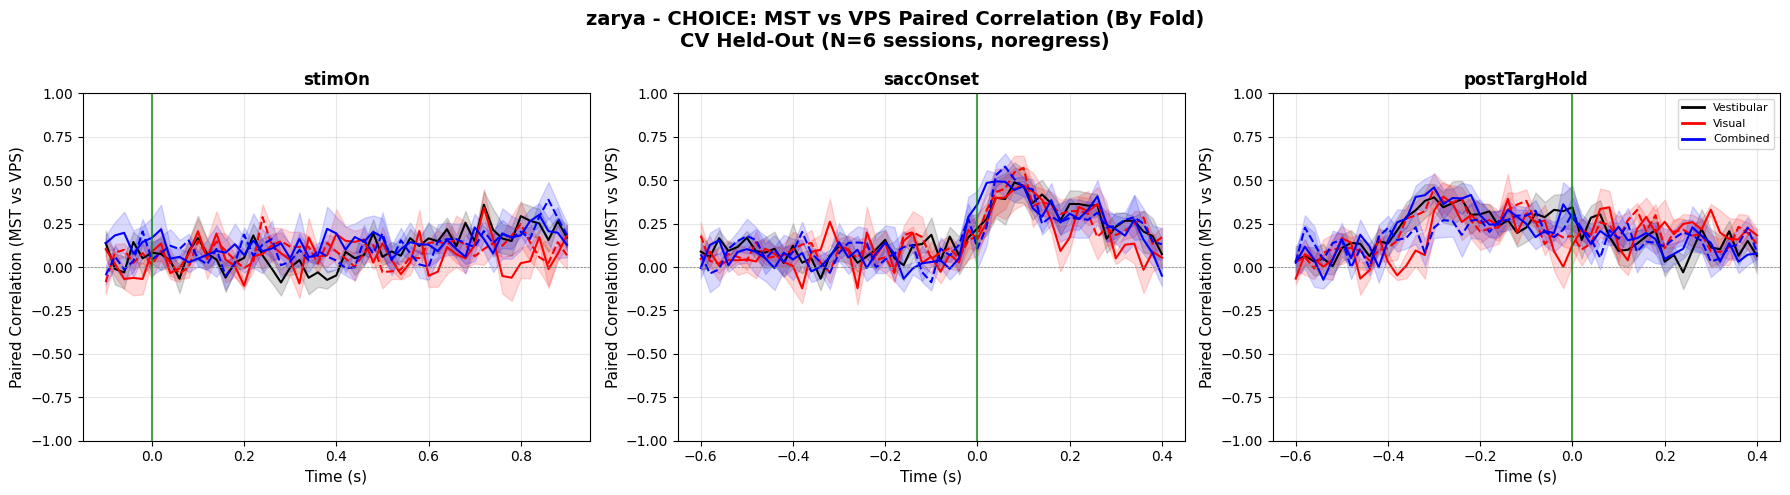


test_zero:

PAIRED CORRELATION BY FOLD (CORRECT)
Target: choice, Alignment: stimOn, Mod: 1, Coh: 1
  20250702: 51 timepoints, 5 folds, mean corr = 0.044
  20250710: 51 timepoints, 5 folds, mean corr = 0.128
  20250523: 51 timepoints, 5 folds, mean corr = 0.068
  20250501: 51 timepoints, 5 folds, mean corr = 0.123
  20250417: 51 timepoints, 5 folds, mean corr = 0.172
  20250602: 51 timepoints, 5 folds, mean corr = 0.124

Summary across 6 sessions:
  Average n_folds per session: 5.0
  Mean correlation: 0.110
  Median correlation: 0.090
  Max correlation: 0.315
  Min correlation: -0.056

PAIRED CORRELATION BY FOLD (CORRECT)
Target: choice, Alignment: stimOn, Mod: 2, Coh: 1
  20250702: 51 timepoints, 5 folds, mean corr = 0.060
  20250710: 51 timepoints, 5 folds, mean corr = 0.084
  20250523: 51 timepoints, 5 folds, mean corr = 0.048
  20250501: 51 timepoints, 5 folds, mean corr = 0.151
  20250417: 51 timepoints, 5 folds, mean corr = 0.023
  20250602: 51 timepoints, 5 folds, mean corr = 0.

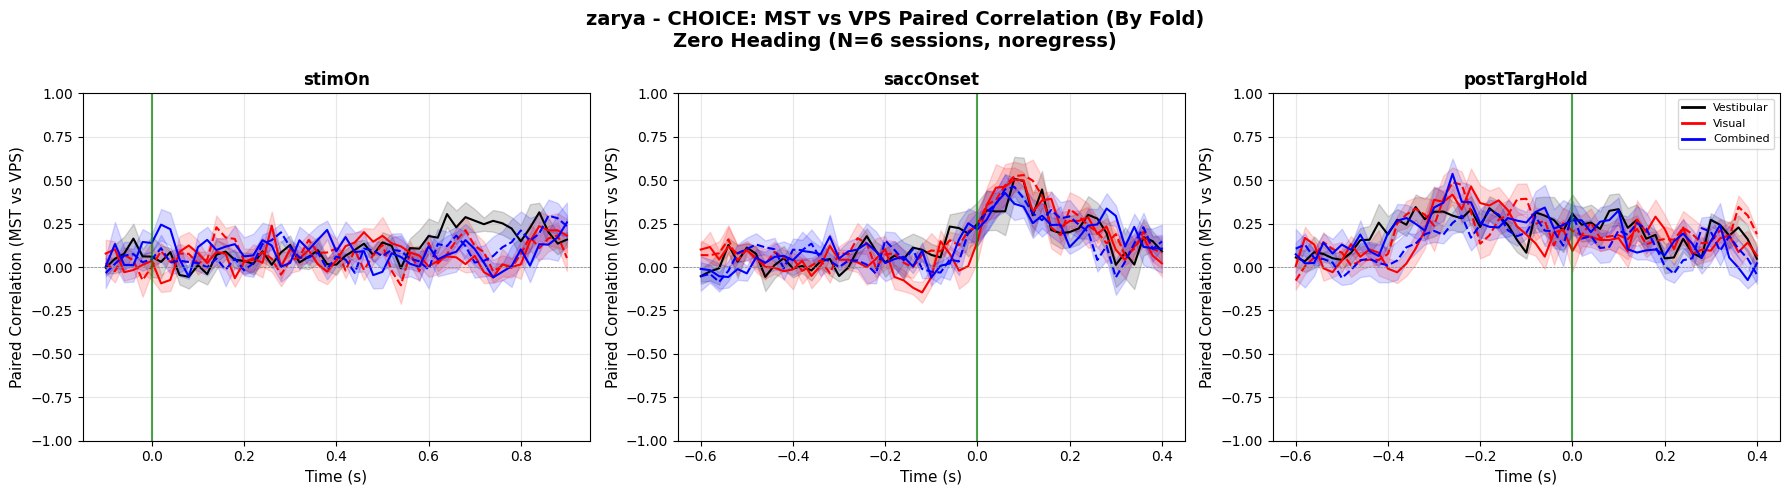


test_large:

PAIRED CORRELATION BY FOLD (CORRECT)
Target: choice, Alignment: stimOn, Mod: 1, Coh: 1
  20250702: 51 timepoints, 5 folds, mean corr = 0.071
  20250710: 51 timepoints, 5 folds, mean corr = 0.088
  20250523: 51 timepoints, 5 folds, mean corr = 0.067
  20250501: 51 timepoints, 5 folds, mean corr = 0.071
  20250417: 51 timepoints, 5 folds, mean corr = 0.165
  20250602: 51 timepoints, 5 folds, mean corr = 0.107

Summary across 6 sessions:
  Average n_folds per session: 5.0
  Mean correlation: 0.095
  Median correlation: 0.079
  Max correlation: 0.274
  Min correlation: -0.049

PAIRED CORRELATION BY FOLD (CORRECT)
Target: choice, Alignment: stimOn, Mod: 2, Coh: 1
  20250702: 51 timepoints, 5 folds, mean corr = 0.036
  20250710: 51 timepoints, 5 folds, mean corr = 0.070
  20250523: 51 timepoints, 5 folds, mean corr = 0.064
  20250501: 51 timepoints, 5 folds, mean corr = 0.194
  20250417: 51 timepoints, 5 folds, mean corr = 0.071
  20250602: 51 timepoints, 5 folds, mean corr = 0

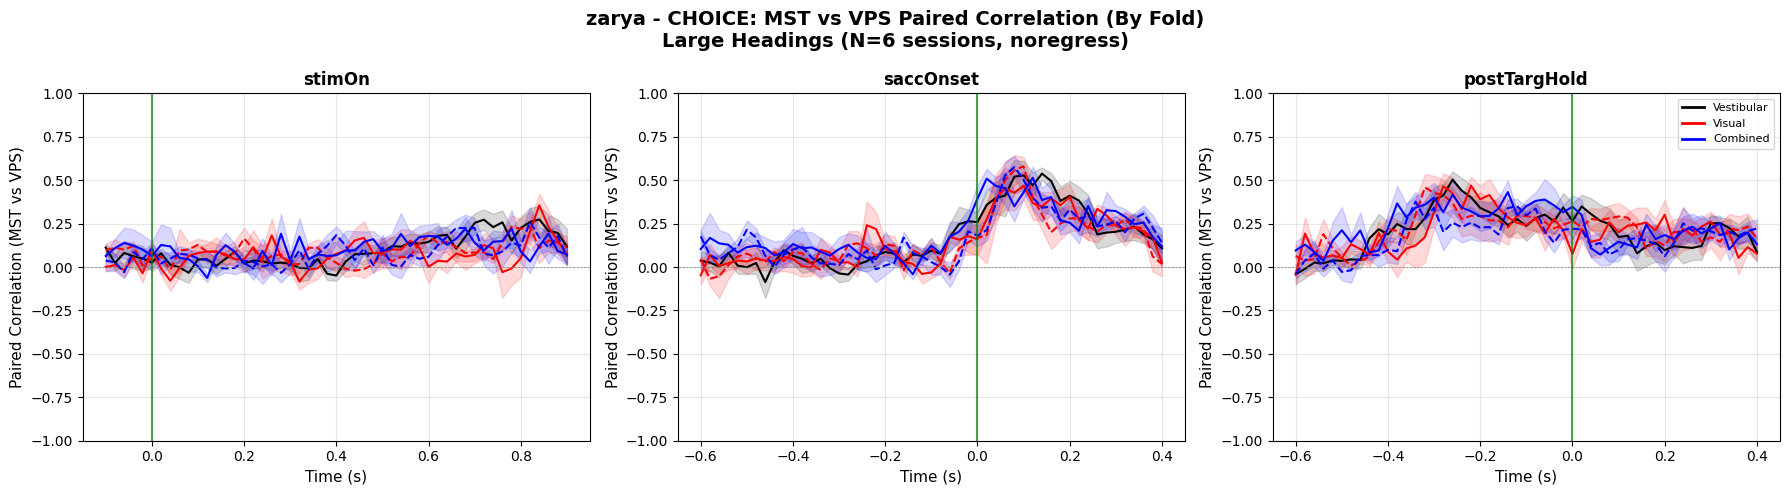


TARGET: PDW

test_cv:

PAIRED CORRELATION BY FOLD (CORRECT)
Target: PDW, Alignment: stimOn, Mod: 1, Coh: 1
  20250702: 51 timepoints, 5 folds, mean corr = -0.055
  20250710: 51 timepoints, 5 folds, mean corr = 0.080
  20250523: 51 timepoints, 5 folds, mean corr = -0.004
  20250501: 51 timepoints, 5 folds, mean corr = 0.551
  20250417: 51 timepoints, 3 folds, mean corr = 0.039
  20250602: 51 timepoints, 5 folds, mean corr = 0.000

Summary across 6 sessions:
  Average n_folds per session: 4.7
  Mean correlation: 0.102
  Median correlation: 0.110
  Max correlation: 0.256
  Min correlation: -0.069

PAIRED CORRELATION BY FOLD (CORRECT)
Target: PDW, Alignment: stimOn, Mod: 2, Coh: 1
  20250702: 51 timepoints, 5 folds, mean corr = -0.024
  20250710: 51 timepoints, 5 folds, mean corr = 0.067
  20250523: 51 timepoints, 5 folds, mean corr = 0.062
  20250501: 51 timepoints, 5 folds, mean corr = 0.386
  20250417: 51 timepoints, 5 folds, mean corr = 0.017
  20250602: 51 timepoints, 5 folds, mean c

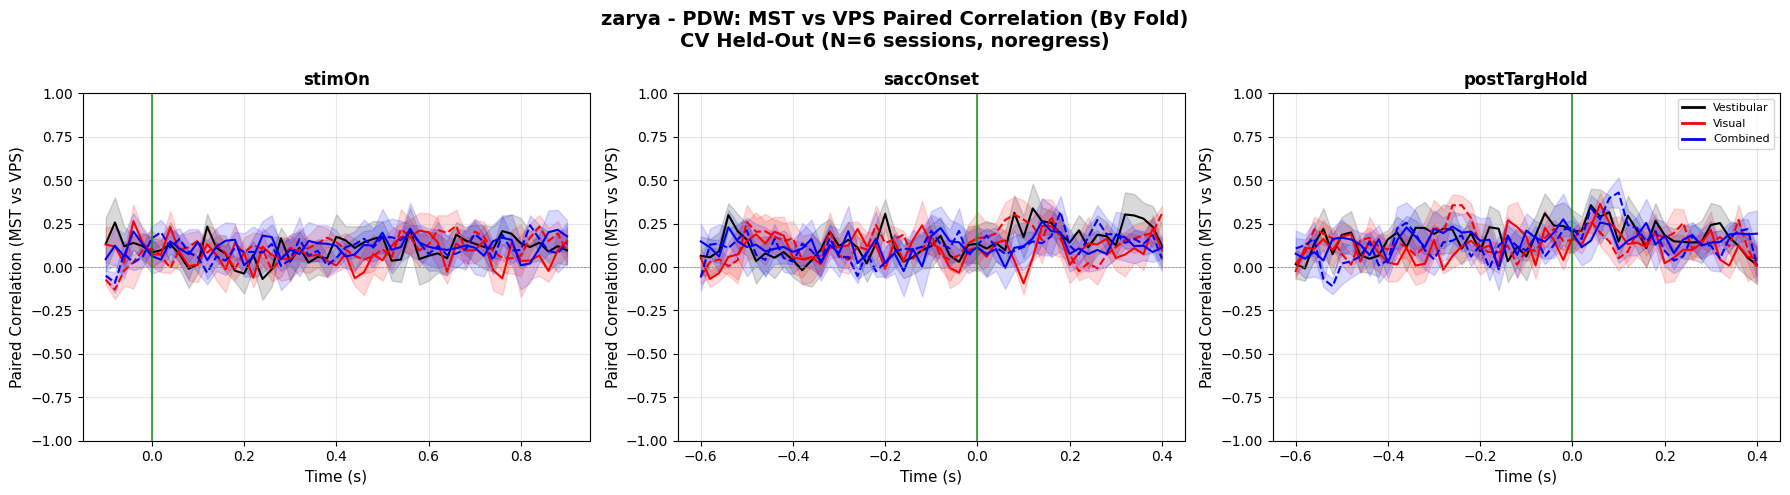


test_zero:

PAIRED CORRELATION BY FOLD (CORRECT)
Target: PDW, Alignment: stimOn, Mod: 1, Coh: 1
  20250702: 51 timepoints, 5 folds, mean corr = 0.018
  20250710: 51 timepoints, 5 folds, mean corr = 0.105
  20250523: 51 timepoints, 5 folds, mean corr = 0.001
  20250501: 51 timepoints, 5 folds, mean corr = 0.407
  20250417: 51 timepoints, 3 folds, mean corr = 0.004
  20250602: 51 timepoints, 5 folds, mean corr = 0.055

Summary across 6 sessions:
  Average n_folds per session: 4.7
  Mean correlation: 0.098
  Median correlation: 0.097
  Max correlation: 0.259
  Min correlation: -0.077

PAIRED CORRELATION BY FOLD (CORRECT)
Target: PDW, Alignment: stimOn, Mod: 2, Coh: 1
  20250702: 51 timepoints, 5 folds, mean corr = 0.031
  20250710: 51 timepoints, 5 folds, mean corr = 0.034
  20250523: 51 timepoints, 5 folds, mean corr = 0.053
  20250501: 51 timepoints, 5 folds, mean corr = 0.283
  20250417: 51 timepoints, 5 folds, mean corr = -0.005
  20250602: 51 timepoints, 5 folds, mean corr = 0.031



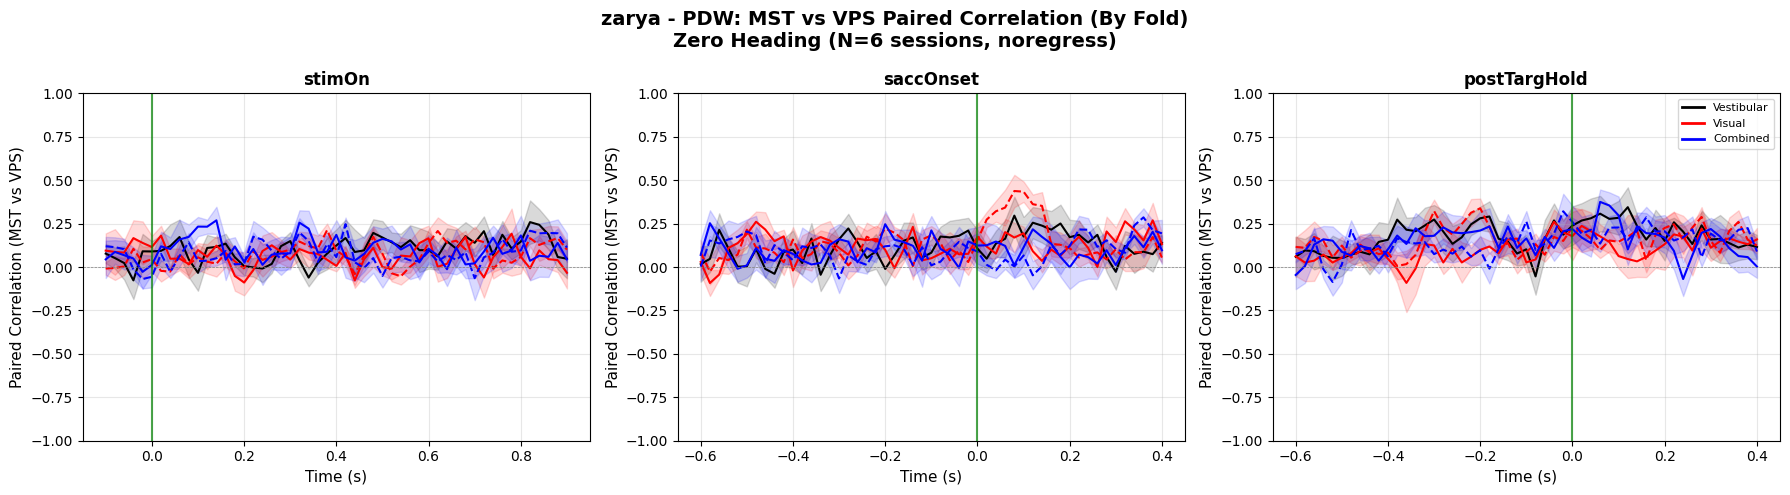


test_large:

PAIRED CORRELATION BY FOLD (CORRECT)
Target: PDW, Alignment: stimOn, Mod: 1, Coh: 1
  20250702: 51 timepoints, 5 folds, mean corr = 0.003
  20250710: 51 timepoints, 5 folds, mean corr = 0.054
  20250523: 51 timepoints, 5 folds, mean corr = 0.021
  20250501: 51 timepoints, 5 folds, mean corr = 0.471
  20250417: 51 timepoints, 3 folds, mean corr = 0.047
  20250602: 51 timepoints, 5 folds, mean corr = 0.021

Summary across 6 sessions:
  Average n_folds per session: 4.7
  Mean correlation: 0.103
  Median correlation: 0.102
  Max correlation: 0.225
  Min correlation: -0.017

PAIRED CORRELATION BY FOLD (CORRECT)
Target: PDW, Alignment: stimOn, Mod: 2, Coh: 1
  20250702: 51 timepoints, 5 folds, mean corr = -0.048
  20250710: 51 timepoints, 5 folds, mean corr = 0.024
  20250523: 51 timepoints, 5 folds, mean corr = 0.045
  20250501: 51 timepoints, 5 folds, mean corr = 0.391
  20250417: 51 timepoints, 5 folds, mean corr = 0.016
  20250602: 51 timepoints, 5 folds, mean corr = 0.071


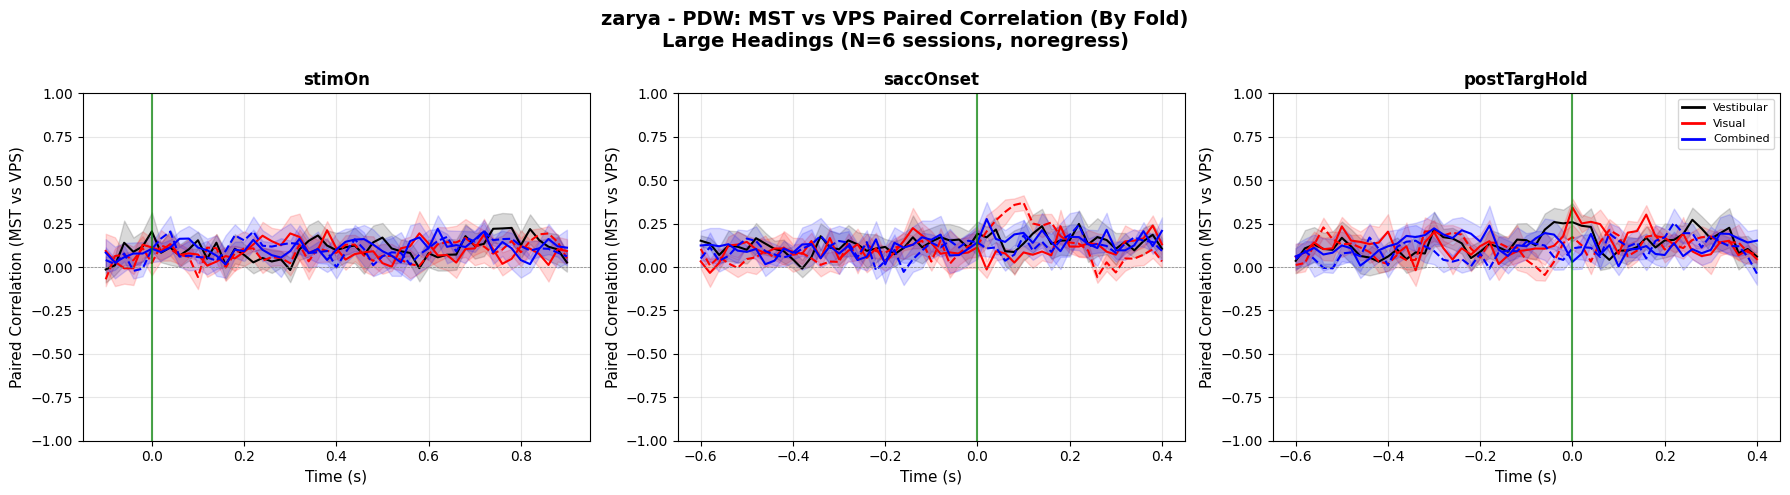


TARGET: STIMULUS

test_cv:

PAIRED CORRELATION BY FOLD (CORRECT)
Target: stimulus, Alignment: stimOn, Mod: 1, Coh: 1
  20250702: 51 timepoints, 5 folds, mean corr = 0.091
  20250710: 51 timepoints, 5 folds, mean corr = 0.014
  20250523: 51 timepoints, 5 folds, mean corr = 0.026
  20250501: 51 timepoints, 5 folds, mean corr = 0.184
  20250417: 51 timepoints, 5 folds, mean corr = 0.106
  20250602: 51 timepoints, 5 folds, mean corr = 0.044

Summary across 6 sessions:
  Average n_folds per session: 5.0
  Mean correlation: 0.078
  Median correlation: 0.071
  Max correlation: 0.255
  Min correlation: -0.096

PAIRED CORRELATION BY FOLD (CORRECT)
Target: stimulus, Alignment: stimOn, Mod: 2, Coh: 1
  20250702: 51 timepoints, 5 folds, mean corr = 0.026
  20250710: 51 timepoints, 5 folds, mean corr = 0.007
  20250523: 51 timepoints, 5 folds, mean corr = 0.015
  20250501: 51 timepoints, 5 folds, mean corr = 0.241
  20250417: 51 timepoints, 5 folds, mean corr = 0.090
  20250602: 51 timepoints, 5 f

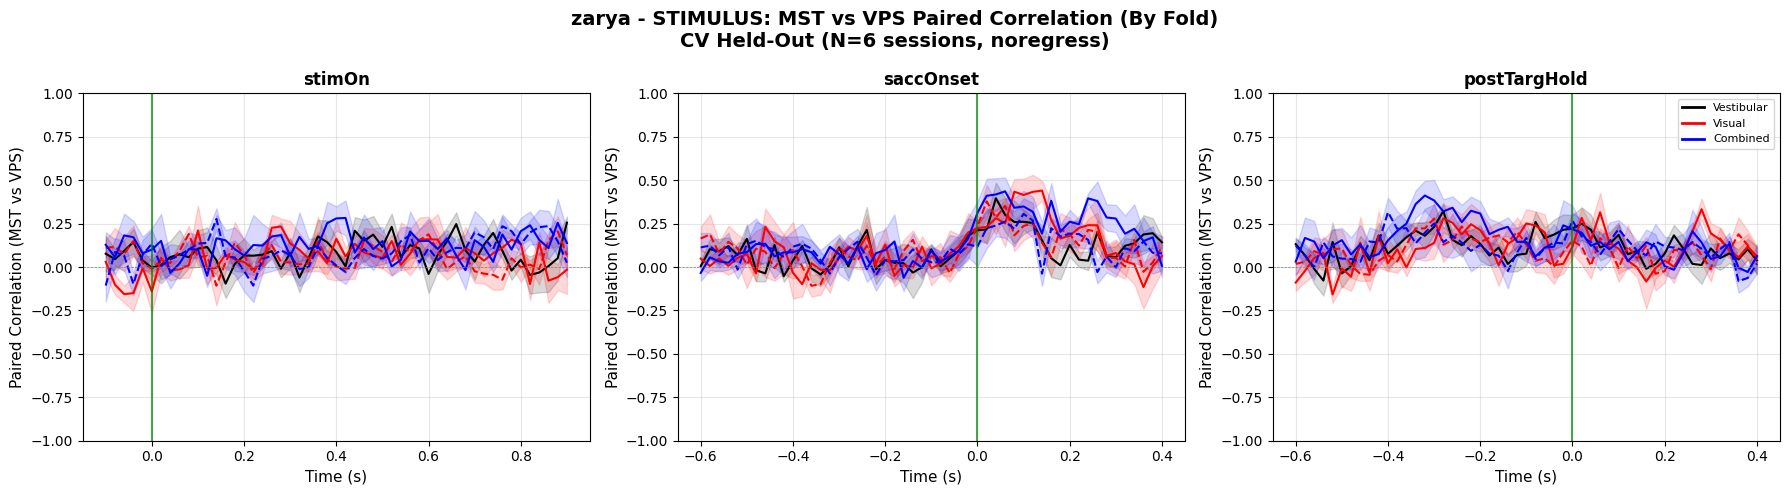


test_large:

PAIRED CORRELATION BY FOLD (CORRECT)
Target: stimulus, Alignment: stimOn, Mod: 1, Coh: 1
  20250702: 51 timepoints, 5 folds, mean corr = 0.021
  20250710: 51 timepoints, 5 folds, mean corr = 0.047
  20250523: 51 timepoints, 5 folds, mean corr = 0.042
  20250501: 51 timepoints, 5 folds, mean corr = 0.180
  20250417: 51 timepoints, 5 folds, mean corr = 0.046
  20250602: 51 timepoints, 5 folds, mean corr = 0.050

Summary across 6 sessions:
  Average n_folds per session: 5.0
  Mean correlation: 0.064
  Median correlation: 0.063
  Max correlation: 0.171
  Min correlation: -0.059

PAIRED CORRELATION BY FOLD (CORRECT)
Target: stimulus, Alignment: stimOn, Mod: 2, Coh: 1
  20250702: 51 timepoints, 5 folds, mean corr = 0.029
  20250710: 51 timepoints, 5 folds, mean corr = 0.021
  20250523: 51 timepoints, 5 folds, mean corr = -0.000
  20250501: 51 timepoints, 5 folds, mean corr = 0.187
  20250417: 51 timepoints, 5 folds, mean corr = 0.043
  20250602: 51 timepoints, 5 folds, mean cor

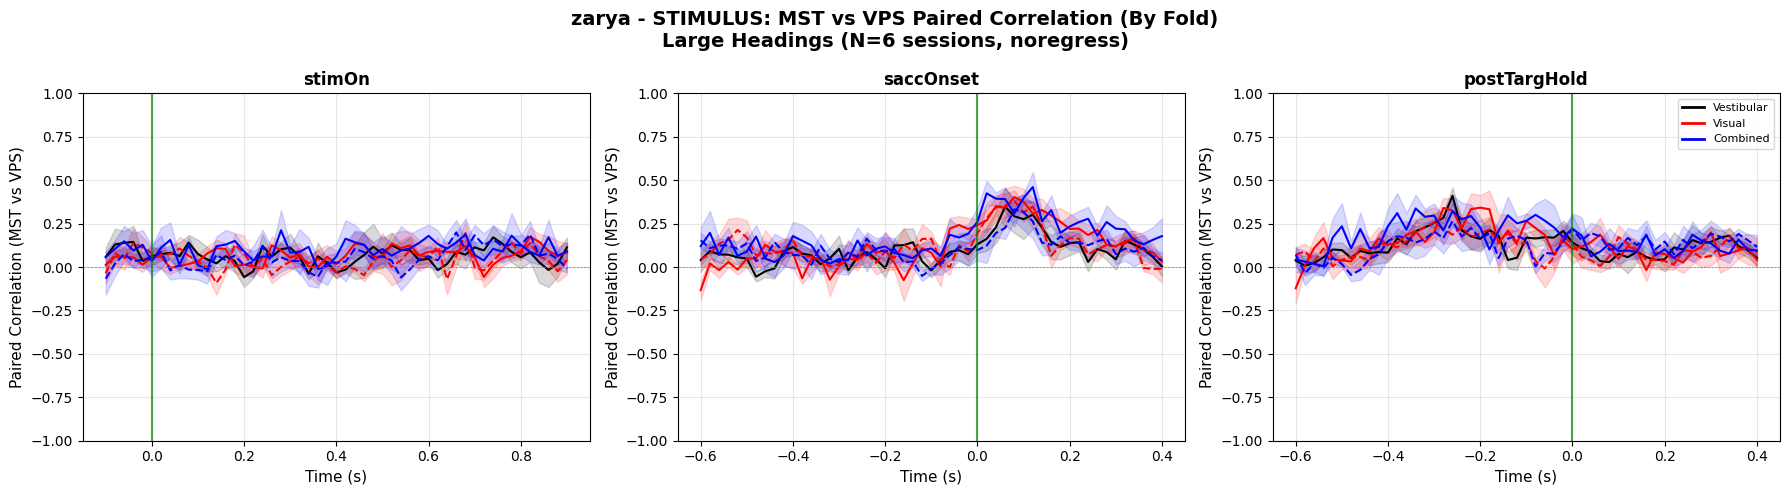


Done!


In [31]:
def plot_paired_correlation_corrected(subject, dates, target, test_set, 
                                     time_axes, regress_type='noregress'):
    """Plot CORRECTED paired correlation across all conditions."""
    
    alignments = ['stimOn', 'saccOnset', 'postTargHold']
    mod_colors = {1: 'black', 2: 'red', 3: 'blue'}
    mod_labels = {1: 'Vestibular', 2: 'Visual', 3: 'Combined'}
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for col, alignment in enumerate(alignments):
        ax = axes[col]
        time_axis = np.array(time_axes.get(alignment, []))
        
        for mod in [1, 2, 3]:
            for coh in [1, 2]:
                if mod == 1 and coh == 2:
                    continue
                
                result = compare_areas_paired_by_fold(
                    subject, dates, target, alignment, mod, coh,
                    test_set=test_set, regress_type=regress_type
                )
                
                if result is None:
                    continue
                
                mean_corr = result['correlations_by_time']
                sem_corr = result['correlations_sem']
                time_points = np.arange(len(mean_corr))
                
                # Convert to time values
                if len(time_axis) > 0:
                    valid_mask = time_points < len(time_axis)
                    time_values = time_axis[time_points[valid_mask].astype(int)]
                    corr_plot = mean_corr[valid_mask]
                    sem_plot = sem_corr[valid_mask]
                else:
                    time_values = time_points
                    corr_plot = mean_corr
                    sem_plot = sem_corr
                
                linestyle = '-' if (mod == 1 or coh == 2) else '--'
                
                ax.plot(time_values, corr_plot, 
                       color=mod_colors[mod], linestyle=linestyle, linewidth=1.5)
                ax.fill_between(time_values, corr_plot - sem_plot, corr_plot + sem_plot,
                               color=mod_colors[mod], alpha=0.15)
        
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
        ax.axvline(0, color='green', linestyle='-', linewidth=1.5, alpha=0.7)
        
        ax.set_xlabel('Time (s)', fontsize=11)
        ax.set_ylabel('Paired Correlation (MST vs VPS)', fontsize=11)
        ax.set_ylim([-1, 1])
        ax.set_title(alignment, fontsize=12, fontweight='bold')
        ax.grid(alpha=0.3)
        
        if col == 2:
            for mod_id in [1, 2, 3]:
                ax.plot([], [], color=mod_colors[mod_id], linewidth=2, label=mod_labels[mod_id])
            ax.legend(loc='best', fontsize=8)
    
    test_set_names = {'test_cv': 'CV Held-Out', 'test_zero': 'Zero Heading', 'test_large': 'Large Headings'}
    n_sessions = len(dates)
    
    plt.suptitle(f'{subject} - {target.upper()}: MST vs VPS Paired Correlation (By Fold)\n'
                 f'{test_set_names.get(test_set, test_set)} (N={n_sessions} sessions, {regress_type})', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'A1_PAIRED_by_fold_{target}_{test_set}_{regress_type}.png', dpi=150, bbox_inches='tight')
    plt.show()


# =============================================================================
# EXECUTE
# =============================================================================

if __name__ == "__main__":
    subject = "zarya"
    dates = ["20250702", "20250710", "20250523", "20250501", "20250417", "20250602"]
    time_axes = load_time_axes_only(subject, "20250602")
    regress_type = 'noregress'
    
    print("\n" + "="*80)
    print("CORRECTED: Paired Correlation by Fold")
    print("="*80)
    
    for target in ['choice', 'PDW', 'stimulus']:
        print(f"\n{'='*80}")
        print(f"TARGET: {target.upper()}")
        print(f"{'='*80}")
        
        test_sets = ['test_cv', 'test_zero', 'test_large'] if target != 'stimulus' else ['test_cv', 'test_large']
        
        for test_set in test_sets:
            print(f"\n{test_set}:")
            plot_paired_correlation_corrected(subject, dates, target, test_set, 
                                            time_axes, regress_type)
    
    print("\n" + "="*80)
    print("Done!")
    print("="*80)

### correlation correct / pdw

Loaded dots3DMP data: zarya20250602dots3DMP_processed.npz
Loaded dots3DMPtuning data: zarya20250602dots3DMPtuning_processed.npz
Loaded dots3DMP configuration for subject: zarya

ANALYSIS 2: Individual Categories by Modality/Coherence

Analyzing target: pdw

COMBINED CATEGORIES CORRELATION (with subsampling)
Target: pdw, Alignment: stimOn, Mod: 1, Coh: 1
Subsample iterations: 10, Smooth window: 3
  20250702:
    correct             : avg_n=145.0, valid= 51, corr=0.034
    error               : avg_n=  9.0, valid= 51, corr=0.010
  20250710:
    correct             : avg_n=153.0, valid= 51, corr=0.121
    error               : avg_n= 15.0, valid= 51, corr=0.086
  20250523:
    correct             : avg_n=160.0, valid= 51, corr=0.195
    error               : avg_n=  8.0, valid= 51, corr=0.244
  20250501:
    correct             : avg_n=159.0, valid= 51, corr=0.509
    error               : avg_n=  8.0, valid= 51, corr=0.332
  20250417:
    correct             : avg_n= 88.0, valid= 51, cor

C:\Users\fetschlab\AppData\Local\Temp\ipykernel_5076\1324321568.py:226: RuntimeWarning: Mean of empty slice
  mean_corr = np.nanmean(category_correlations[cat])


  20250710:
    correct             : avg_n=165.0, valid= 51, corr=0.102
    error               : avg_n=  3.0, valid= 17, corr=0.722
  20250523:
    correct             : avg_n=164.0, valid= 51, corr=0.043
    error               : avg_n=  4.0, valid= 51, corr=0.076
  20250501:
    correct             : avg_n=165.0, valid= 51, corr=0.422
    error               : avg_n=  2.0, valid=  0, corr=nan
  20250602:
    correct             : avg_n=164.0, valid= 51, corr=0.061
    error               : avg_n=  4.0, valid= 51, corr=0.071

correct             : mean_corr=0.157, valid=51/51, avg_n=162.4

error               : mean_corr=0.141, valid=51/51, avg_n=2.6

COMBINED CATEGORIES CORRELATION (with subsampling)
Target: pdw, Alignment: saccOnset, Mod: 2, Coh: 2
Subsample iterations: 10, Smooth window: 3
  20250702:
    correct             : avg_n=154.0, valid=  0, corr=nan
    error               : avg_n=  0.0, valid=  0, corr=nan
  20250710:
    correct             : avg_n=165.0, valid= 51, c

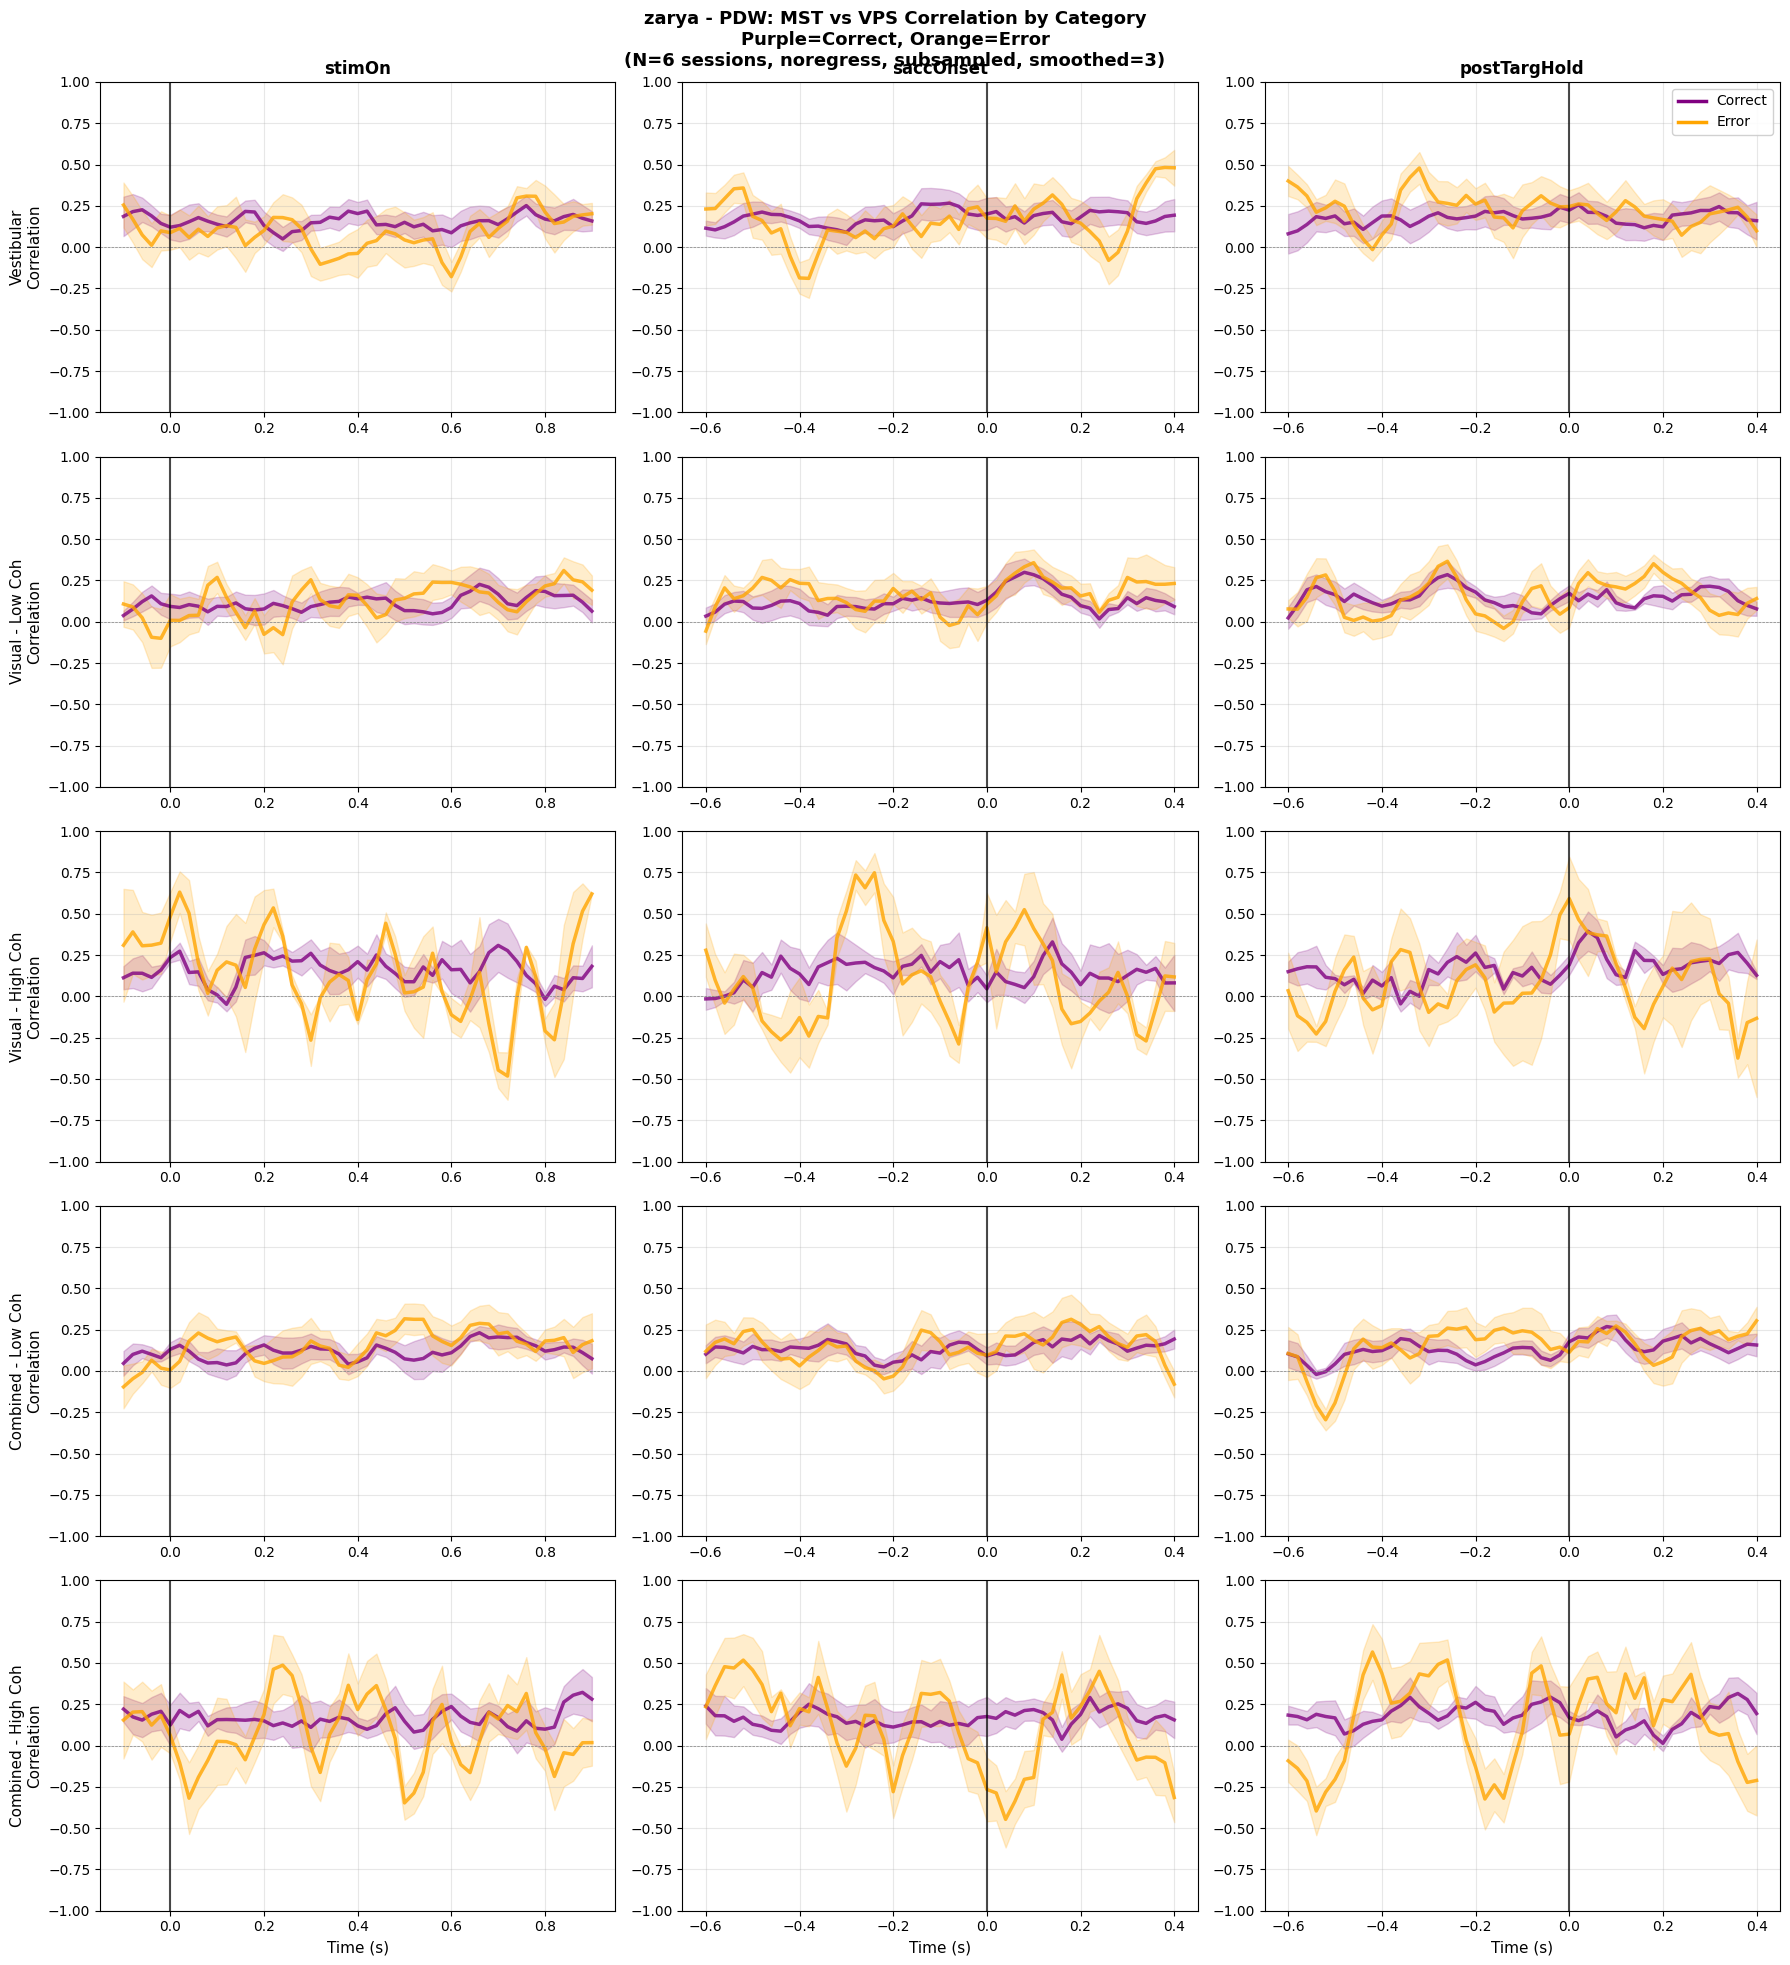


Done!


In [5]:
import numpy as np
from scipy.ndimage import uniform_filter1d

# =============================================================================
# CELL 4E: Analysis 2 - Individual Categories with Subsampling and Smoothing
# =============================================================================

def compare_areas_by_categories(subject, dates, target, alignment, mod, coh, 
                                regress_type='noregress', n_subsample_iterations=100,
                                smooth_window=3):
    """
    Compute paired correlation with COMBINED categories using SUBSAMPLING:
    1. Correct (all PDW)
    2. Error (all PDW)
    
    Uses subsampling to match trial counts across categories for fair comparison.
    Applies temporal smoothing over adjacent time windows.
    """
    
    print(f"\n{'='*60}")
    print(f"COMBINED CATEGORIES CORRELATION (with subsampling)")
    print(f"Target: {target}, Alignment: {alignment}, Mod: {mod}, Coh: {coh}")
    print(f"Subsample iterations: {n_subsample_iterations}, Smooth window: {smooth_window}")
    print(f"{'='*60}")
    
    # Two categories: accuracy only
    categories = ['correct', 'error']
    category_labels = {
        'correct': 'Correct',
        'error': 'Error'
    }
    
    session_correlations = {cat: [] for cat in categories}
    session_trial_counts = {cat: [] for cat in categories}
    
    for date in dates:
        results_mst = load_decoder_results(subject, date, 'MST', target, alignment, 
                                          mod, coh, regress_type=regress_type)
        results_vps = load_decoder_results(subject, date, 'VPS', target, alignment, 
                                          mod, coh, regress_type=regress_type)
        
        if results_mst is None or results_vps is None:
            continue
        
        trial_results_mst = results_mst['trial_results']
        trial_results_vps = results_vps['trial_results']
        
        # Pool by time
        mst_by_time = {}
        vps_by_time = {}
        
        for r in trial_results_mst:
            t = r['time']
            for test_set in ['test_cv', 'test_large']:
                if test_set in r and len(r[test_set].get('y_proba', [])) > 0:
                    if t not in mst_by_time:
                        mst_by_time[t] = {'y_proba': [], 'behavior': {}}
                    
                    y_proba = r[test_set].get('y_proba', np.array([]))
                    behavior = r[test_set].get('behavior', {})
                    
                    if len(y_proba) > 0:
                        if len(mst_by_time[t]['y_proba']) == 0:
                            mst_by_time[t]['y_proba'] = y_proba
                            mst_by_time[t]['behavior'] = behavior
                        else:
                            mst_by_time[t]['y_proba'] = np.concatenate([
                                mst_by_time[t]['y_proba'], y_proba])
                            for key in behavior:
                                if key in mst_by_time[t]['behavior']:
                                    mst_by_time[t]['behavior'][key] = np.concatenate([
                                        mst_by_time[t]['behavior'][key], behavior[key]])
                                else:
                                    mst_by_time[t]['behavior'][key] = behavior[key]
        
        for r in trial_results_vps:
            t = r['time']
            for test_set in ['test_cv', 'test_large']:
                if test_set in r and len(r[test_set].get('y_proba', [])) > 0:
                    if t not in vps_by_time:
                        vps_by_time[t] = {'y_proba': [], 'behavior': {}}
                    
                    y_proba = r[test_set].get('y_proba', np.array([]))
                    behavior = r[test_set].get('behavior', {})
                    
                    if len(y_proba) > 0:
                        if len(vps_by_time[t]['y_proba']) == 0:
                            vps_by_time[t]['y_proba'] = y_proba
                            vps_by_time[t]['behavior'] = behavior
                        else:
                            vps_by_time[t]['y_proba'] = np.concatenate([
                                vps_by_time[t]['y_proba'], y_proba])
                            for key in behavior:
                                if key in vps_by_time[t]['behavior']:
                                    vps_by_time[t]['behavior'][key] = np.concatenate([
                                        vps_by_time[t]['behavior'][key], behavior[key]])
                                else:
                                    vps_by_time[t]['behavior'][key] = behavior[key]
        
        common_times = sorted(set(mst_by_time.keys()) & set(vps_by_time.keys()))
        
        if len(common_times) == 0:
            continue
        
        category_correlations = {cat: [] for cat in categories}
        category_n_trials = {cat: [] for cat in categories}
        
        for t in common_times:
            mst_data = mst_by_time[t]
            vps_data = vps_by_time[t]
            
            mst_proba = mst_data['y_proba']
            vps_proba = vps_data['y_proba']
            mst_behavior = mst_data['behavior']
            
            if len(mst_proba) == 0 or len(vps_proba) == 0:
                for cat in categories:
                    category_correlations[cat].append(np.nan)
                    category_n_trials[cat].append(0)
                continue
            
            n_trials = min(len(mst_proba), len(vps_proba))
            mst_proba = mst_proba[:n_trials]
            vps_proba = vps_proba[:n_trials]
            
            choice = mst_behavior.get('choice', np.array([]))[:n_trials]
            heading_ind = mst_behavior.get('headingInd', np.array([]))[:n_trials]
            
            if len(choice) != n_trials or len(heading_ind) != n_trials:
                for cat in categories:
                    category_correlations[cat].append(np.nan)
                    category_n_trials[cat].append(0)
                continue
            
            choice = (choice - 1).astype(int) if np.max(choice) > 1 else choice.astype(int)
            
            correct_answer = (heading_ind > 4).astype(int)
            is_correct = (choice == correct_answer)
            
            mst_proba_clip = np.clip(mst_proba, 1e-10, 1 - 1e-10)
            vps_proba_clip = np.clip(vps_proba, 1e-10, 1 - 1e-10)
            mst_dv = np.log(mst_proba_clip / (1 - mst_proba_clip))
            vps_dv = np.log(vps_proba_clip / (1 - vps_proba_clip))
            
            # Define category masks - correct vs error only
            categories_masks = {
                'correct': is_correct,
                'error': ~is_correct
            }
            
            # Find minimum trial count across both categories at this time point
            trial_counts = {cat: np.sum(mask) for cat, mask in categories_masks.items()}
            min_trials = min(trial_counts.values())
            
            # Store actual trial counts (before subsampling)
            for cat in categories:
                category_n_trials[cat].append(trial_counts[cat])
            
            # Compute correlations with subsampling to match trial counts
            if min_trials > 1:  # Need at least 2 points for correlation
                for cat, mask in categories_masks.items():
                    n_cat = trial_counts[cat]
                    
                    if n_cat > 1:
                        mst_cat_full = mst_dv[mask]
                        vps_cat_full = vps_dv[mask]
                        
                        # Check for variance
                        if np.std(mst_cat_full) == 0 or np.std(vps_cat_full) == 0:
                            category_correlations[cat].append(np.nan)
                            continue
                        
                        # Subsample to match minimum trial count
                        if n_cat > min_trials:
                            # Multiple iterations of subsampling
                            corrs_subsample = []
                            for _ in range(n_subsample_iterations):
                                idx = np.random.choice(n_cat, min_trials, replace=False)
                                mst_sub = mst_cat_full[idx]
                                vps_sub = vps_cat_full[idx]
                                
                                if np.std(mst_sub) > 0 and np.std(vps_sub) > 0:
                                    corr = np.corrcoef(mst_sub, vps_sub)[0, 1]
                                    if not np.isnan(corr):
                                        corrs_subsample.append(corr)
                            
                            if len(corrs_subsample) > 0:
                                category_correlations[cat].append(np.mean(corrs_subsample))
                            else:
                                category_correlations[cat].append(np.nan)
                        else:
                            # Already at minimum, use all trials
                            corr = np.corrcoef(mst_cat_full, vps_cat_full)[0, 1]
                            category_correlations[cat].append(corr)
                    else:
                        category_correlations[cat].append(np.nan)
            else:
                # Not enough trials in any category
                for cat in categories:
                    category_correlations[cat].append(np.nan)
        
        # Apply temporal smoothing to correlations
        for cat in categories:
            if len(category_correlations[cat]) > 0:
                # Convert to array for smoothing
                corr_array = np.array(category_correlations[cat])
                
                # Handle NaNs
                nan_mask = np.isnan(corr_array)
                if not np.all(nan_mask):
                    if np.any(~nan_mask):
                        smoothed = uniform_filter1d(corr_array, size=smooth_window, 
                                                   mode='nearest')
                        # Keep NaNs where they were originally
                        smoothed[nan_mask] = np.nan
                        category_correlations[cat] = smoothed.tolist()
        
        for cat in categories:
            session_correlations[cat].append(np.array(category_correlations[cat]))
            session_trial_counts[cat].append(np.array(category_n_trials[cat]))
        
        print(f"  {date}:")
        for cat in categories:
            mean_n = np.mean(category_n_trials[cat])
            n_valid = np.sum(~np.isnan(category_correlations[cat]))
            mean_corr = np.nanmean(category_correlations[cat])
            print(f"    {cat:20s}: avg_n={mean_n:5.1f}, valid={n_valid:3d}, corr={mean_corr:.3f}")
    
    if all(len(session_correlations[cat]) == 0 for cat in categories):
        return None
    
    # Average across sessions
    results_by_category = {}
    
    for cat in categories:
        if len(session_correlations[cat]) == 0:
            results_by_category[cat] = None
            continue
        
        min_timepoints = min([len(c) for c in session_correlations[cat]])
        
        correlations_array = np.array([c[:min_timepoints] for c in session_correlations[cat]])
        trial_counts_array = np.array([c[:min_timepoints] for c in session_trial_counts[cat]])
        
        mean_corr = np.nanmean(correlations_array, axis=0)
        std_corr = np.nanstd(correlations_array, axis=0)
        sem_corr = std_corr / np.sqrt(np.sum(~np.isnan(correlations_array), axis=0))
        
        mean_n_trials = np.mean(trial_counts_array, axis=0)
        
        results_by_category[cat] = {
            'correlations_by_time': mean_corr,
            'correlations_std': std_corr,
            'correlations_sem': sem_corr,
            'mean_n_trials': mean_n_trials,
            'n_timepoints': min_timepoints,
            'n_sessions': len(session_correlations[cat])
        }
        
        n_valid = np.sum(~np.isnan(mean_corr))
        overall_mean_n = np.mean(mean_n_trials)
        print(f"\n{cat:20s}: mean_corr={np.nanmean(mean_corr):.3f}, "
              f"valid={n_valid}/{min_timepoints}, avg_n={overall_mean_n:.1f}")
    
    return results_by_category


# =============================================================================
# CELL 5E: Plot Individual Categories (5x3 grid - by modality/coherence)
# =============================================================================

def plot_paired_correlation_by_categories(subject, dates, target, time_axes, 
                                         regress_type='noregress', 
                                         n_subsample_iterations=100,
                                         smooth_window=3):
    """
    Plot correlation with individual categories in a 5x3 grid:
    Row 1: Vestibular (high coherence only)
    Row 2: Visual - Low coherence
    Row 3: Visual - High coherence
    Row 4: Combined - Low coherence
    Row 5: Combined - High coherence
    
    Purple = Correct
    Orange = Error
    
    Parameters:
    -----------
    target : str
        Which decoder to analyze: 'choice', 'stimulus', or 'PDW'
    """
    
    alignments = ['stimOn', 'saccOnset', 'postTargHold']
    
    # Define the 5 rows: (modality, coherence)
    condition_rows = [
        (1, 1, 'Vestibular'),
        (2, 1, 'Visual - Low Coh'),
        (2, 2, 'Visual - High Coh'),
        (3, 1, 'Combined - Low Coh'),
        (3, 2, 'Combined - High Coh')
    ]
    
    # Define plotting properties for each category
    plot_properties = {
        'correct': {'color': 'purple', 'linestyle': '-', 'label': 'Correct'},
        'error': {'color': 'orange', 'linestyle': '-', 'label': 'Error'}
    }
    
    categories = ['correct', 'error']
    
    fig, axes = plt.subplots(5, 3, figsize=(18, 20))
    
    # Loop through each condition (row)
    for row, (mod, coh, row_label) in enumerate(condition_rows):
        # Loop through each alignment (column)
        for col, alignment in enumerate(alignments):
            ax = axes[row, col]
            time_axis = np.array(time_axes.get(alignment, []))
            
            # Get results for this modality/coherence
            results_by_cat = compare_areas_by_categories(
                subject, dates, target, alignment, mod, coh,
                regress_type=regress_type,
                n_subsample_iterations=n_subsample_iterations,
                smooth_window=smooth_window
            )
            
            if results_by_cat is None:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center', 
                       transform=ax.transAxes)
                continue
            
            # Plot both categories
            for cat in categories:
                if results_by_cat[cat] is None:
                    continue
                
                result = results_by_cat[cat]
                mean_corr = result['correlations_by_time']
                sem_corr = result['correlations_sem']
                time_points = np.arange(len(mean_corr))
                
                if len(time_axis) > 0:
                    valid_mask = time_points < len(time_axis)
                    time_values = time_axis[time_points[valid_mask].astype(int)]
                    corr_plot = mean_corr[valid_mask]
                    sem_plot = sem_corr[valid_mask]
                else:
                    time_values = time_points
                    corr_plot = mean_corr
                    sem_plot = sem_corr
                
                props = plot_properties[cat]
                ax.plot(time_values, corr_plot, 
                       color=props['color'], 
                       linestyle=props['linestyle'], 
                       linewidth=2.5, 
                       alpha=0.8)
                ax.fill_between(time_values, corr_plot - sem_plot, corr_plot + sem_plot,
                               color=props['color'], alpha=0.2)
            
            ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
            ax.axvline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.7)
            ax.set_ylim([-1, 1])
            ax.grid(alpha=0.3)
            
            # Y-axis label only on leftmost column
            if col == 0:
                ax.set_ylabel(f'{row_label}\nCorrelation', fontsize=11)
            
            # X-axis label only on bottom row
            if row == 4:
                ax.set_xlabel('Time (s)', fontsize=11)
            
            # Title on top row
            if row == 0:
                ax.set_title(alignment, fontsize=12, fontweight='bold')
            
            # Legend on top-right subplot
            if row == 0 and col == 2:
                for cat in categories:
                    props = plot_properties[cat]
                    ax.plot([], [], color=props['color'], 
                           linestyle=props['linestyle'], 
                           linewidth=2.5, 
                           label=props['label'])
                ax.legend(loc='best', fontsize=10, framealpha=0.9)
    
    n_sessions = len(dates)
    plt.suptitle(f'{subject} - {target.upper()}: MST vs VPS Correlation by Category\n'
                 f'Purple=Correct, Orange=Error\n'
                 f'(N={n_sessions} sessions, {regress_type}, subsampled, smoothed={smooth_window})', 
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'A2_paired_categories_modality_{target}_{regress_type}_smooth{smooth_window}.png', 
                dpi=150, bbox_inches='tight')
    plt.show()


# =============================================================================
# EXECUTE
# =============================================================================

if __name__ == "__main__":
    subject = "zarya"
    dates = ["20250702", "20250710", "20250523", "20250501", "20250417", "20250602"]
    time_axes = load_time_axes_only(subject, "20250602")
    regress_type = 'noregress'
    
    print("\n" + "="*80)
    print("ANALYSIS 2: Individual Categories by Modality/Coherence")
    print("="*80)
    
    SMOOTH_WINDOW = 3
    
    # Choose which target to analyze
    TARGET = 'pdw'  # Change this to 'choice', 'stimulus', or 'PDW'
    
    print(f"\nAnalyzing target: {TARGET}")
    plot_paired_correlation_by_categories(subject, dates, TARGET, time_axes, 
                                         regress_type, 
                                         n_subsample_iterations=10,
                                         smooth_window=SMOOTH_WINDOW)
    
    print("\nDone!")

###  high , low pdw

Loaded dots3DMP data: zarya20250602dots3DMP_processed.npz
Loaded dots3DMPtuning data: zarya20250602dots3DMPtuning_processed.npz
Loaded dots3DMP configuration for subject: zarya

Generating plots for STIMULUS decoder


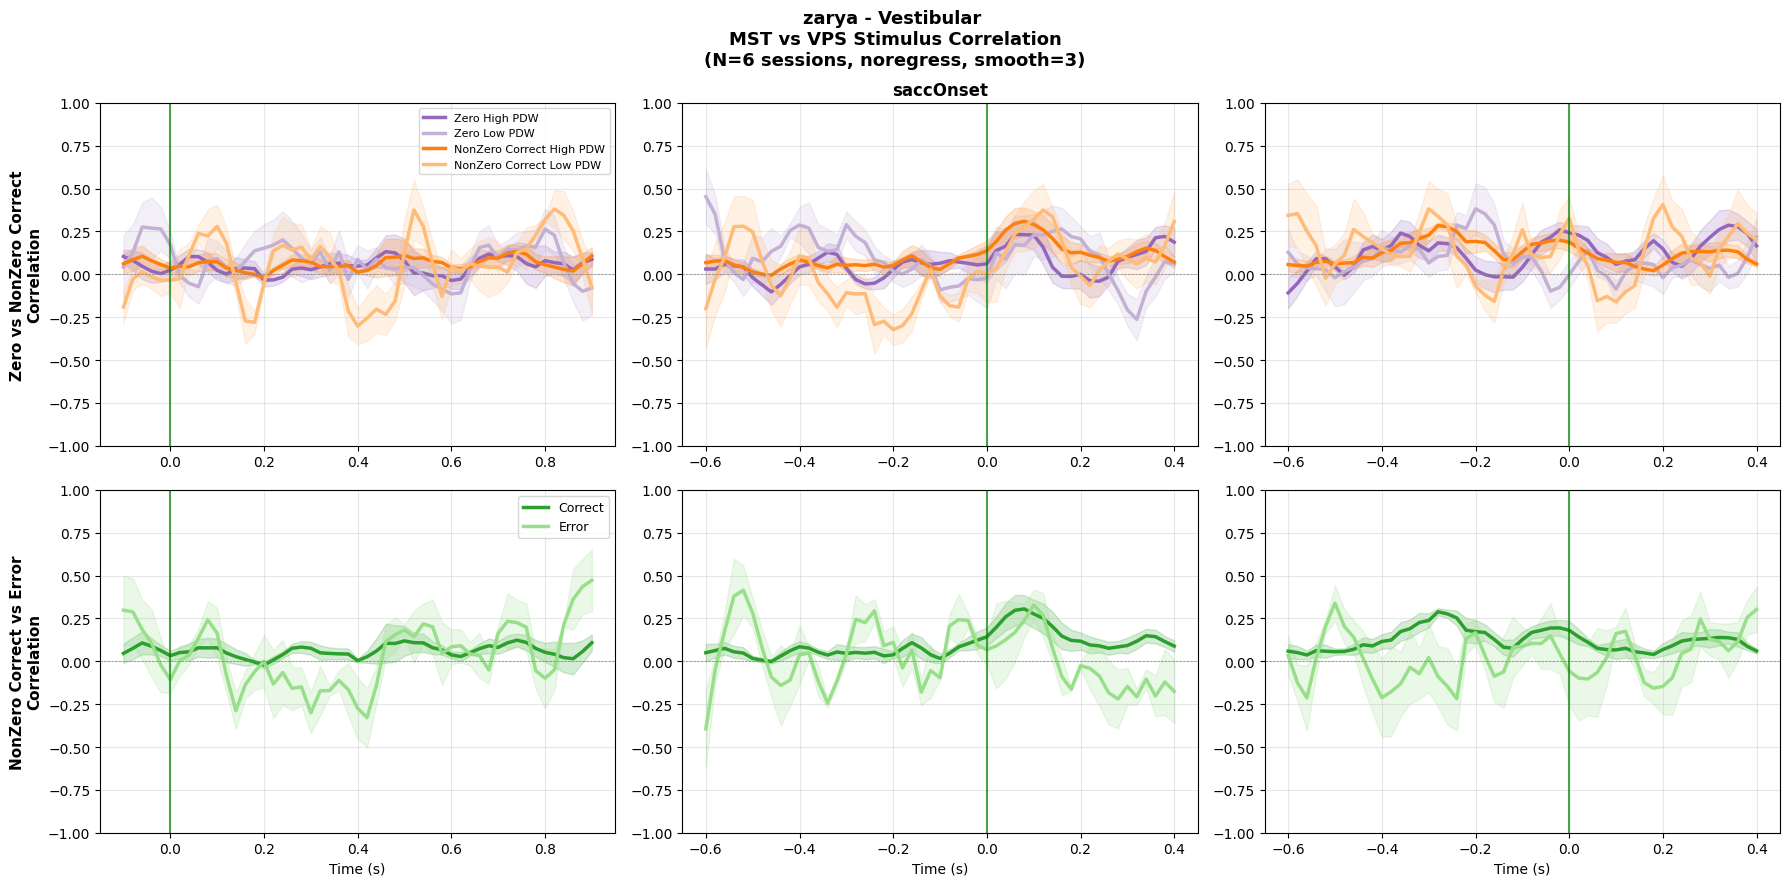

Saved: A2_stimulus_Vestibular_coh1_noregress_smooth3.png


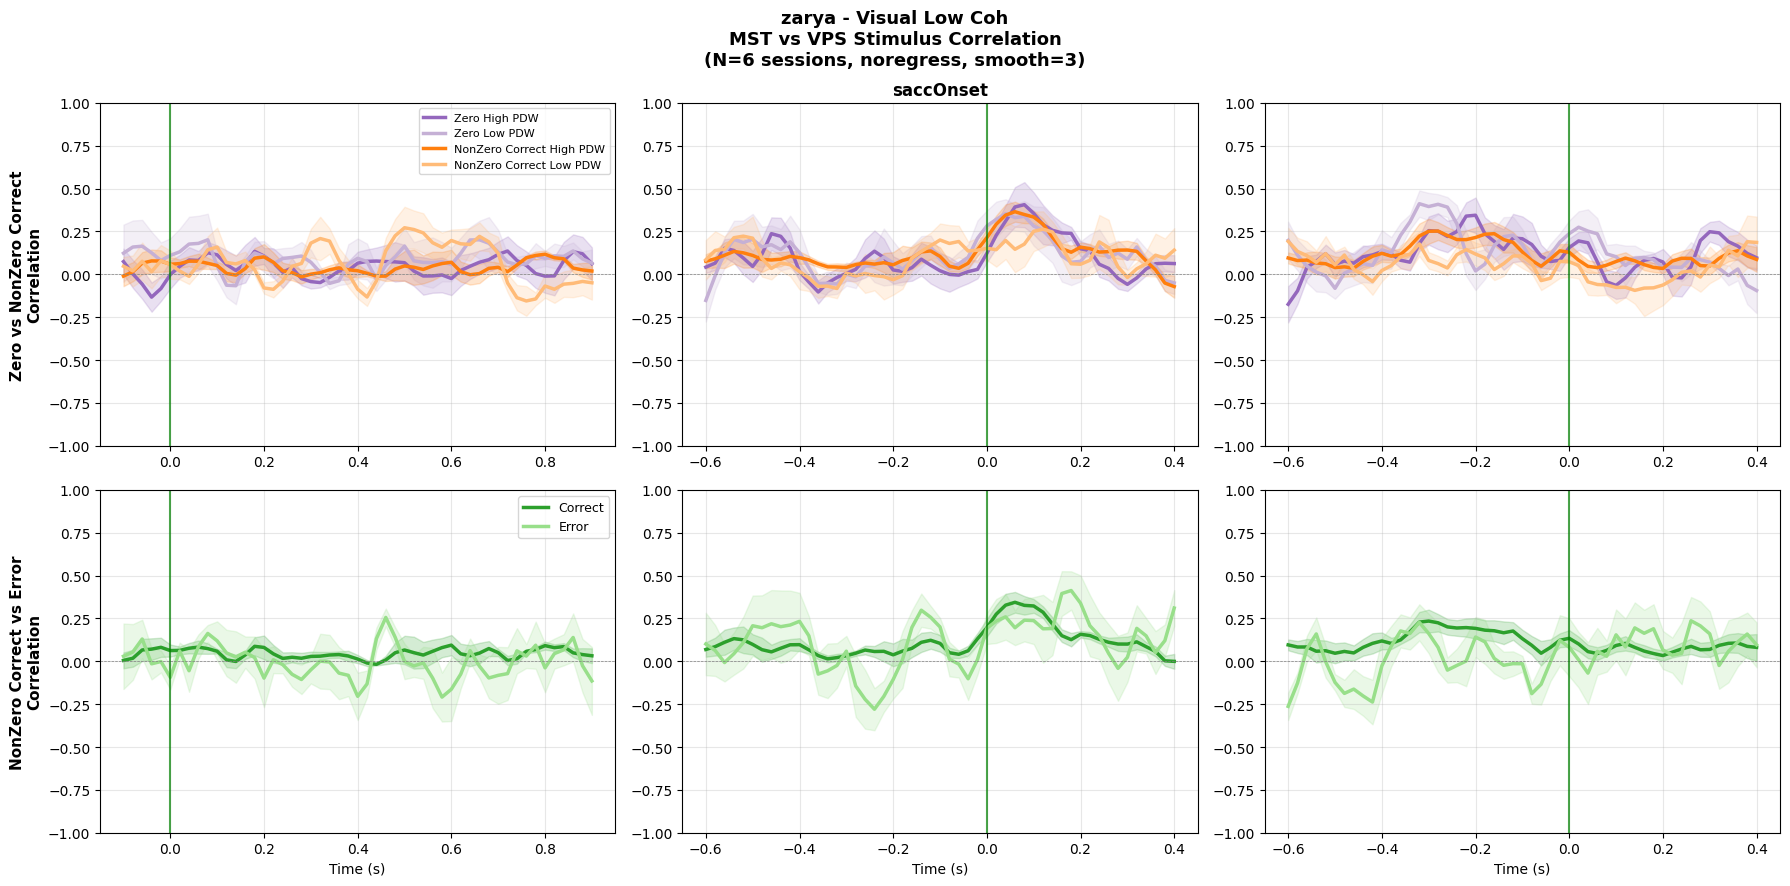

Saved: A2_stimulus_Visual_coh1_noregress_smooth3.png


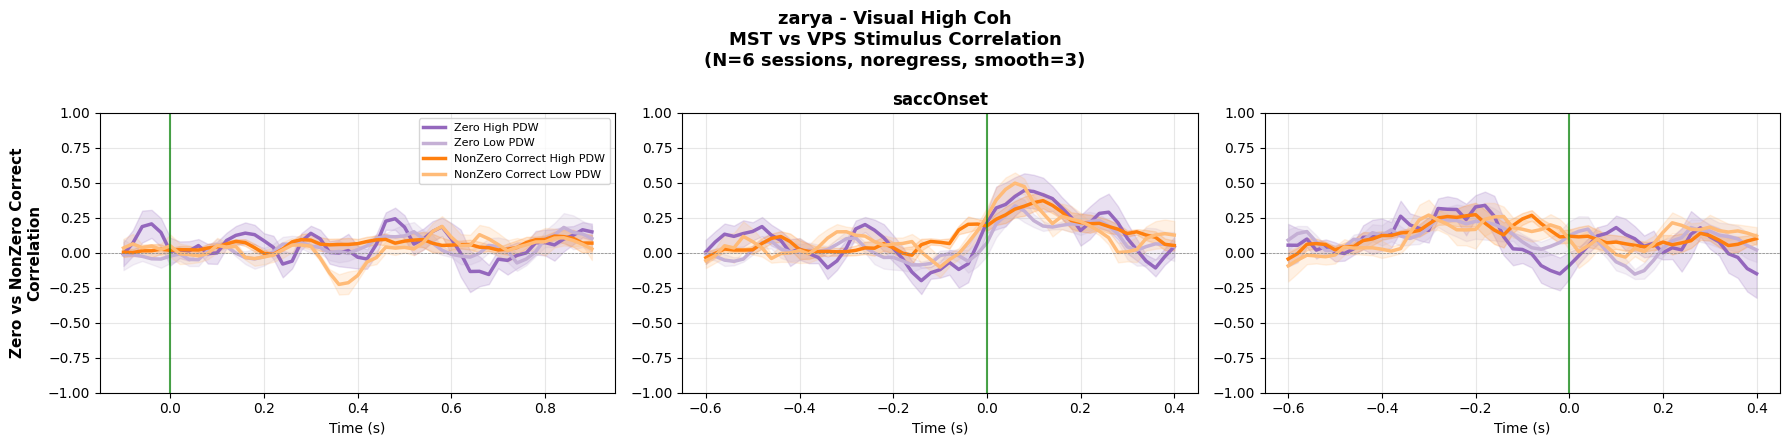

Saved: A2_stimulus_Visual_coh2_noregress_smooth3.png


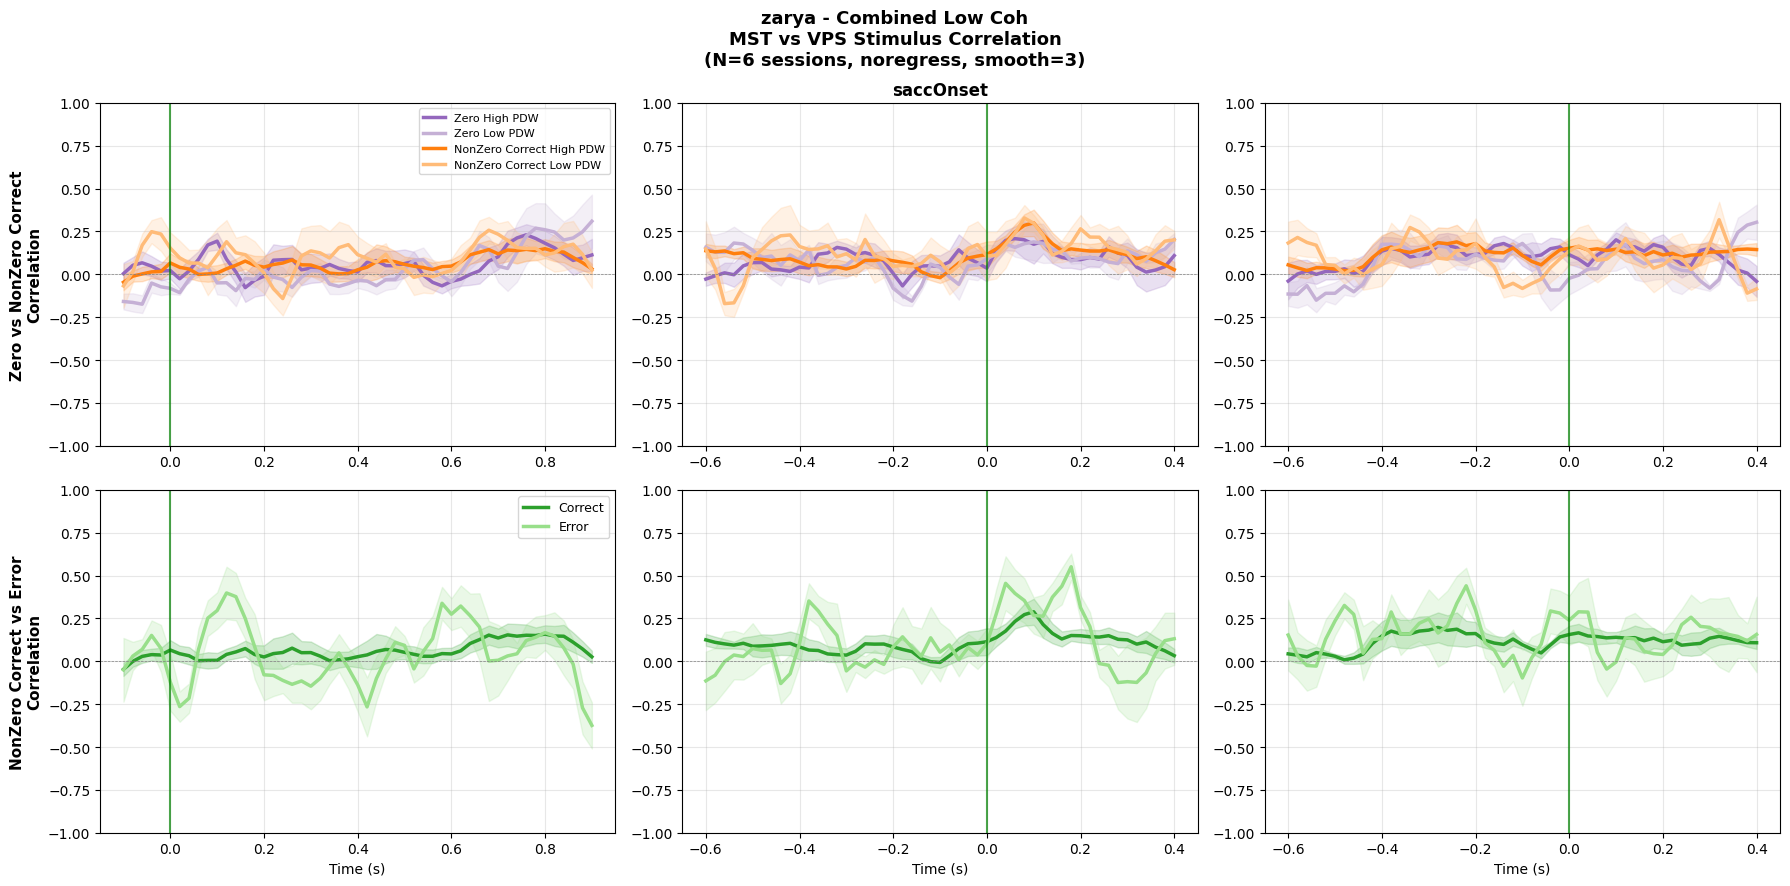

Saved: A2_stimulus_Combined_coh1_noregress_smooth3.png


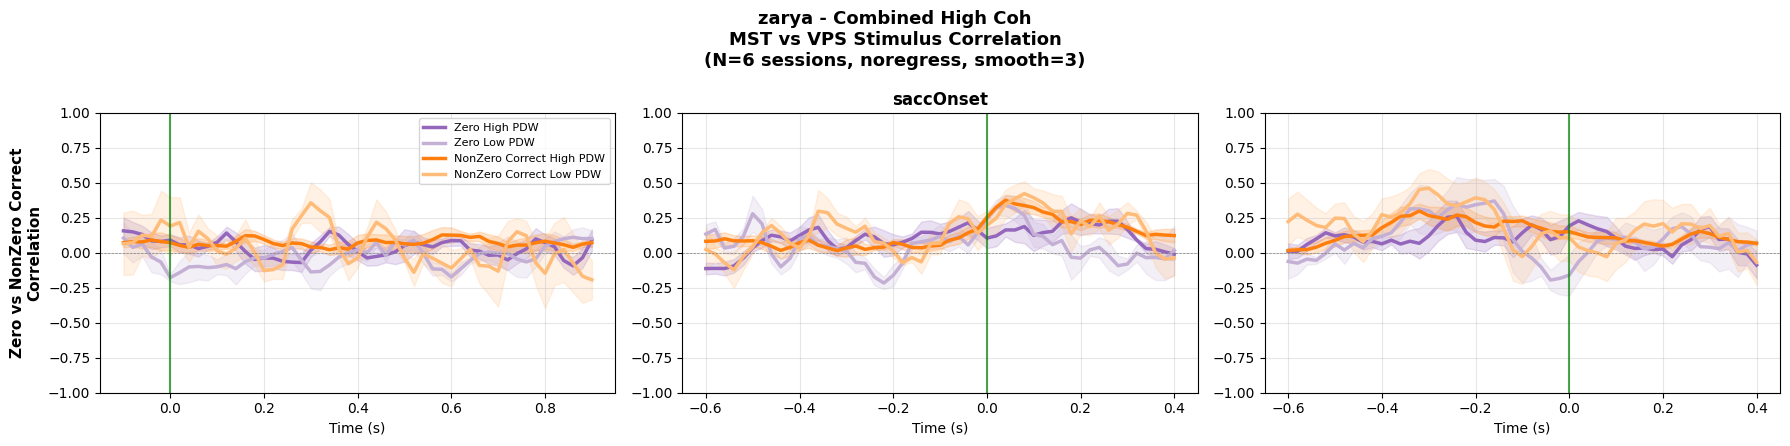

Saved: A2_stimulus_Combined_coh2_noregress_smooth3.png

All plots completed!


In [17]:
from scipy.ndimage import uniform_filter1d
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# Core correlation function (reusable for all trial types)
# =============================================================================

def compute_correlation_by_category(subject, dates, target, alignment, mod, coh,
                                   test_keys, filter_func, categories,
                                   regress_type='noregress', smooth_window=3):
    """
    Generic function to compute correlations split by categories.
    """
    
    session_correlations = {cat: [] for cat in categories}
    session_trial_counts = {cat: [] for cat in categories}
    
    for date in dates:
        results_mst = load_decoder_results(subject, date, 'MST', target, alignment, 
                                          mod, coh, regress_type=regress_type)
        results_vps = load_decoder_results(subject, date, 'VPS', target, alignment, 
                                          mod, coh, regress_type=regress_type)
        
        if results_mst is None or results_vps is None:
            continue
        
        # Organize by time and fold
        mst_by_time_fold = {}
        vps_by_time_fold = {}
        
        for area_results, area_dict in [(results_mst['trial_results'], mst_by_time_fold),
                                        (results_vps['trial_results'], vps_by_time_fold)]:
            for r in area_results:
                t, fold = r['time'], r['fold']
                combined_data = {'y_proba': [], 'behavior': {}}
                
                for test_key in test_keys:
                    if test_key in r and r[test_key].get('n_test', 0) > 0:
                        y_proba = r[test_key].get('y_proba', np.array([]))
                        behavior = r[test_key].get('behavior', {})
                        
                        if len(y_proba) > 0:
                            if len(combined_data['y_proba']) == 0:
                                combined_data['y_proba'] = y_proba
                                combined_data['behavior'] = behavior
                            else:
                                combined_data['y_proba'] = np.concatenate([combined_data['y_proba'], y_proba])
                                for key in behavior:
                                    if key in combined_data['behavior']:
                                        combined_data['behavior'][key] = np.concatenate([
                                            combined_data['behavior'][key], behavior[key]])
                                    else:
                                        combined_data['behavior'][key] = behavior[key]
                
                if len(combined_data['y_proba']) > 0:
                    if t not in area_dict:
                        area_dict[t] = {}
                    area_dict[t][fold] = combined_data
        
        common_times = sorted(set(mst_by_time_fold.keys()) & set(vps_by_time_fold.keys()))
        if len(common_times) == 0:
            continue
        
        category_correlations = {cat: [] for cat in categories}
        category_n_trials = {cat: [] for cat in categories}
        
        for t in common_times:
            mst_folds = mst_by_time_fold[t]
            vps_folds = vps_by_time_fold[t]
            common_folds = sorted(set(mst_folds.keys()) & set(vps_folds.keys()))
            
            if len(common_folds) == 0:
                for cat in categories:
                    category_correlations[cat].append(np.nan)
                    category_n_trials[cat].append(0)
                continue
            
            for cat in categories:
                fold_correlations = []
                fold_n_trials = []
                
                for fold in common_folds:
                    mst_data = mst_folds[fold]
                    vps_data = vps_folds[fold]
                    
                    mst_proba = mst_data.get('y_proba', np.array([]))
                    vps_proba = vps_data.get('y_proba', np.array([]))
                    
                    if len(mst_proba) == 0 or len(vps_proba) == 0:
                        continue
                    
                    n_trials = min(len(mst_proba), len(vps_proba))
                    mst_proba = mst_proba[:n_trials]
                    vps_proba = vps_proba[:n_trials]
                    
                    # Get category masks
                    masks = filter_func(mst_data, n_trials)
                    if masks is None or cat not in masks:
                        continue
                    
                    mask = masks[cat]
                    n_cat = np.sum(mask)
                    
                    if n_cat > 1:
                        # Convert to log-odds
                        mst_proba_clip = np.clip(mst_proba, 1e-10, 1 - 1e-10)
                        vps_proba_clip = np.clip(vps_proba, 1e-10, 1 - 1e-10)
                        mst_dv = np.log(mst_proba_clip / (1 - mst_proba_clip))
                        vps_dv = np.log(vps_proba_clip / (1 - vps_proba_clip))
                        
                        mst_cat = mst_dv[mask]
                        vps_cat = vps_dv[mask]
                        
                        if np.std(mst_cat) > 0 and np.std(vps_cat) > 0:
                            corr = np.corrcoef(mst_cat, vps_cat)[0, 1]
                            fold_correlations.append(corr)
                            fold_n_trials.append(n_cat)
                
                if len(fold_correlations) > 0:
                    category_correlations[cat].append(np.mean(fold_correlations))
                    category_n_trials[cat].append(np.mean(fold_n_trials))
                else:
                    category_correlations[cat].append(np.nan)
                    category_n_trials[cat].append(0)
        
        # Apply temporal smoothing
        for cat in categories:
            if len(category_correlations[cat]) > 0:
                corr_array = np.array(category_correlations[cat])
                valid_mask = ~np.isnan(corr_array)
                if np.any(valid_mask):
                    smoothed = uniform_filter1d(corr_array, size=smooth_window, mode='nearest')
                    smoothed[~valid_mask] = np.nan
                    category_correlations[cat] = smoothed.tolist()
        
        for cat in categories:
            if len(category_correlations[cat]) > 0:
                session_correlations[cat].append(np.array(category_correlations[cat]))
                session_trial_counts[cat].append(np.array(category_n_trials[cat]))
    
    if all(len(session_correlations[cat]) == 0 for cat in categories):
        return None
    
    # Average across sessions
    results_by_category = {}
    for cat in categories:
        if len(session_correlations[cat]) == 0:
            results_by_category[cat] = None
            continue
        
        min_timepoints = min([len(c) for c in session_correlations[cat]])
        correlations_array = np.array([c[:min_timepoints] for c in session_correlations[cat]])
        trial_counts_array = np.array([c[:min_timepoints] for c in session_trial_counts[cat]])
        
        mean_corr = np.nanmean(correlations_array, axis=0)
        std_corr = np.nanstd(correlations_array, axis=0)
        sem_corr = std_corr / np.sqrt(np.sum(~np.isnan(correlations_array), axis=0))
        
        results_by_category[cat] = {
            'correlations_by_time': mean_corr,
            'correlations_std': std_corr,
            'correlations_sem': sem_corr,
            'mean_n_trials': np.nanmean(trial_counts_array, axis=0),
            'n_timepoints': min_timepoints,
            'n_sessions': len(session_correlations[cat])
        }
    
    return results_by_category


# =============================================================================
# Filter functions for different trial types
# =============================================================================

def filter_zero_by_pdw(data, n_trials):
    """Split zero heading trials by PDW"""
    pdw = data.get('behavior', {}).get('PDW', np.array([]))[:n_trials]
    if len(pdw) != n_trials:
        return None
    pdw = pdw.astype(int)
    return {
        'high_pdw': (pdw == 1),
        'low_pdw': (pdw == 0)
    }


def filter_correct_by_pdw(data, n_trials):
    """Split correct trials by PDW"""
    choice = data.get('behavior', {}).get('choice', np.array([]))[:n_trials]
    pdw = data.get('behavior', {}).get('PDW', np.array([]))[:n_trials]
    heading_ind = data.get('behavior', {}).get('headingInd', np.array([]))[:n_trials]
    
    if len(choice) != n_trials or len(pdw) != n_trials or len(heading_ind) != n_trials:
        return None
    
    choice = (choice - 1).astype(int) if np.max(choice) > 1 else choice.astype(int)
    pdw = pdw.astype(int)
    correct_answer = (heading_ind > 4).astype(int)
    is_correct = (choice == correct_answer)
    
    return {
        'correct_high_pdw': is_correct & (pdw == 1),
        'correct_low_pdw': is_correct & (pdw == 0)
    }


def filter_correct_vs_error(data, n_trials):
    """Split trials by correct vs error"""
    choice = data.get('behavior', {}).get('choice', np.array([]))[:n_trials]
    heading_ind = data.get('behavior', {}).get('headingInd', np.array([]))[:n_trials]
    
    if len(choice) != n_trials or len(heading_ind) != n_trials:
        return None
    
    choice = (choice - 1).astype(int) if np.max(choice) > 1 else choice.astype(int)
    correct_answer = (heading_ind > 4).astype(int)
    is_correct = (choice == correct_answer)
    
    return {
        'correct': is_correct,
        'error': ~is_correct
    }


# =============================================================================
# Wrapper functions for each analysis
# =============================================================================

def compare_areas_zero_heading_by_pdw(subject, dates, target, alignment, mod, coh, 
                                      regress_type='noregress', smooth_window=3):
    return compute_correlation_by_category(
        subject, dates, target, alignment, mod, coh,
        test_keys=['test_zero'],
        filter_func=filter_zero_by_pdw,
        categories=['high_pdw', 'low_pdw'],
        regress_type=regress_type,
        smooth_window=smooth_window
    )


def compare_areas_correct_nonzero_by_pdw(subject, dates, target, alignment, mod, coh, 
                                         regress_type='noregress', smooth_window=3):
    return compute_correlation_by_category(
        subject, dates, target, alignment, mod, coh,
        test_keys=['test_cv', 'test_large'],
        filter_func=filter_correct_by_pdw,
        categories=['correct_high_pdw', 'correct_low_pdw'],
        regress_type=regress_type,
        smooth_window=smooth_window
    )


def compare_areas_nonzero_correct_vs_error(subject, dates, target, alignment, mod, coh, 
                                           regress_type='noregress', smooth_window=3):
    return compute_correlation_by_category(
        subject, dates, target, alignment, mod, coh,
        test_keys=['test_cv', 'test_large'],
        filter_func=filter_correct_vs_error,
        categories=['correct', 'error'],
        regress_type=regress_type,
        smooth_window=smooth_window
    )


# =============================================================================
# Plotting function - Zero vs Non-zero on same plot
# =============================================================================

def plot_decoder_correlations(subject, dates, time_axes, 
                              target='choice',
                              regress_type='noregress', 
                              smooth_window=3,
                              figsize_x=18,
                              figsize_y_per_row=4.5):
    """
    Plot decoder correlations comparing zero vs non-zero headings.
    
    Layout:
    - Row 1: Zero (purple) vs Non-zero correct (orange), both split by PDW
    - Row 2 (low coh only): Non-zero correct (green) vs error (light green)
    """
    
    alignments = ['stimOn', 'saccOnset', 'postTargHold']
    
    # Color scheme
    zero_colors = {
        'high': '#9467BD',  # Dark purple - zero + high PDW
        'low': '#C5B0D5',   # Light purple - zero + low PDW
    }
    
    nonzero_colors = {
        'high': '#FF7F0E',  # Dark orange - non-zero correct + high PDW
        'low': '#FFBB78',   # Light orange - non-zero correct + low PDW
    }
    
    correct_error_colors = {
        'correct': '#2CA02C',  # Dark green - correct
        'error': '#98DF8A',    # Light green - error
    }
    
    mod_names = {
        1: 'Vestibular',
        2: 'Visual',
        3: 'Combined'
    }
    
    target_labels = {
        'choice': 'Choice',
        'stimulus': 'Stimulus',
        'pdw': 'PDW'
    }
    
    # Loop through modalities
    for mod in [1, 2, 3]:
        mod_name = mod_names[mod]
        
        # For each modality, plot both coherence levels
        for coh in [1, 2]:
            # Vestibular only has coh=1
            if mod == 1 and coh == 2:
                continue
            
            # High coherence: 1 row, Low coherence: 2 rows
            n_rows = 1 if coh == 2 else 2
            
            coh_label = 'High Coh' if coh == 2 else 'Low Coh'
            if mod == 1:
                coh_label = ''
            
            # Adjusted figure size
            fig, axes = plt.subplots(n_rows, 3, figsize=(figsize_x, figsize_y_per_row * n_rows))
            if n_rows == 1:
                axes = axes.reshape(1, -1)
            
            for col, alignment in enumerate(alignments):
                time_axis = np.array(time_axes.get(alignment, []))
                
                # ========================================================================
                # Row 0: Zero (purple) vs Non-zero correct (orange), both by PDW
                # ========================================================================
                ax = axes[0, col]
                
                # Plot zero heading by PDW
                results_zero = compare_areas_zero_heading_by_pdw(subject, dates, target, alignment, mod, coh, regress_type, smooth_window)
                if results_zero:
                    for cat, color, label in [('high_pdw', zero_colors['high'], 'Zero High PDW'), 
                                              ('low_pdw', zero_colors['low'], 'Zero Low PDW')]:
                        if results_zero[cat]:
                            mean_corr = results_zero[cat]['correlations_by_time']
                            sem_corr = results_zero[cat]['correlations_sem']
                            time_values = time_axis[:len(mean_corr)] if len(time_axis) > 0 else np.arange(len(mean_corr))
                            
                            ax.plot(time_values, mean_corr, color=color, linewidth=2.5, label=label)
                            ax.fill_between(time_values, mean_corr - sem_corr, mean_corr + sem_corr, color=color, alpha=0.2)
                
                # Plot non-zero correct by PDW
                results_nonzero = compare_areas_correct_nonzero_by_pdw(subject, dates, target, alignment, mod, coh, regress_type, smooth_window)
                if results_nonzero:
                    for cat, color, label in [('correct_high_pdw', nonzero_colors['high'], 'NonZero Correct High PDW'), 
                                              ('correct_low_pdw', nonzero_colors['low'], 'NonZero Correct Low PDW')]:
                        if results_nonzero[cat]:
                            mean_corr = results_nonzero[cat]['correlations_by_time']
                            sem_corr = results_nonzero[cat]['correlations_sem']
                            time_values = time_axis[:len(mean_corr)] if len(time_axis) > 0 else np.arange(len(mean_corr))
                            
                            ax.plot(time_values, mean_corr, color=color, linewidth=2.5, label=label)
                            ax.fill_between(time_values, mean_corr - sem_corr, mean_corr + sem_corr, color=color, alpha=0.2)
                
                ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
                ax.axvline(0, color='green', linestyle='-', linewidth=1.5, alpha=0.7)
                ax.set_ylim([-1, 1])
                ax.grid(alpha=0.3)
                
                if col == 0:
                    ax.set_ylabel('Zero vs NonZero Correct\nCorrelation', fontsize=11, fontweight='bold')
                    ax.legend(loc='best', fontsize=8, ncol=1)
                if col == 1:
                    ax.set_title(alignment, fontsize=12, fontweight='bold')
                
                # Only add X-axis label if this is the last row
                if n_rows == 1:
                    ax.set_xlabel('Time (s)', fontsize=10)
                
                # ========================================================================
                # Row 1: Correct vs Error (only for low coherence)
                # ========================================================================
                if n_rows == 2:
                    ax = axes[1, col]
                    
                    results_corr_err = compare_areas_nonzero_correct_vs_error(subject, dates, target, alignment, mod, coh, regress_type, smooth_window)
                    if results_corr_err:
                        for cat, color, label in [('correct', correct_error_colors['correct'], 'Correct'), 
                                                  ('error', correct_error_colors['error'], 'Error')]:
                            if results_corr_err[cat]:
                                mean_corr = results_corr_err[cat]['correlations_by_time']
                                sem_corr = results_corr_err[cat]['correlations_sem']
                                time_values = time_axis[:len(mean_corr)] if len(time_axis) > 0 else np.arange(len(mean_corr))
                                
                                ax.plot(time_values, mean_corr, color=color, linewidth=2.5, label=label)
                                ax.fill_between(time_values, mean_corr - sem_corr, mean_corr + sem_corr, color=color, alpha=0.2)
                    
                    ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
                    ax.axvline(0, color='green', linestyle='-', linewidth=1.5, alpha=0.7)
                    ax.set_ylim([-1, 1])
                    ax.grid(alpha=0.3)
                    ax.set_xlabel('Time (s)', fontsize=10)
                    
                    if col == 0:
                        ax.set_ylabel('NonZero Correct vs Error\nCorrelation', fontsize=11, fontweight='bold')
                        ax.legend(loc='best', fontsize=9)
            
            title = f'{subject} - {mod_name} {coh_label}\nMST vs VPS {target_labels[target]} Correlation\n' \
                    f'(N={len(dates)} sessions, {regress_type}, smooth={smooth_window})'
            plt.suptitle(title, fontsize=13, fontweight='bold')
            plt.tight_layout()
            
            filename = f'A2_{target}_{mod_name}_coh{coh}_{regress_type}_smooth{smooth_window}.png'
            plt.savefig(filename, dpi=150, bbox_inches='tight')
            plt.show()
            print(f"Saved: {filename}")


# =============================================================================
# Execute
# =============================================================================

if __name__ == "__main__":
    subject = "zarya"
    dates = ["20250702", "20250710", "20250523", "20250501", "20250417", "20250602"]
    time_axes = load_time_axes_only(subject, "20250602")
    
    # Plot all three decoder types
    for target in ['stimulus']:
        print(f"\n{'='*60}")
        print(f"Generating plots for {target.upper()} decoder")
        print(f"{'='*60}")
        
        plot_decoder_correlations(subject, dates, time_axes, 
                                  target=target,
                                  regress_type='noregress', 
                                  smooth_window=3,
                                  figsize_x=18,
                                  figsize_y_per_row=4.5)
    
    print("\nAll plots completed!")